---
title: 'Chapter 3: Statistical Models for Time Series'
jupyter:
  kernelspec:
    display_name: Python (timeSeries-course)
    language: python
    name: timeseries-course
editor_options: 
  chunk_output_type: console
---

## Statistical Models for Time Series

### Topics Covered:

1.  Introduction to Statistical Time Series Models
2.  Building Blocks: AR, MA, and ARMA Processes
3.  ARIMA Models
4.  Seasonal ARIMA (SARIMA) Models
5.  SARIMAX: Incorporating Exogenous Variables
6.  Automatic Model Selection
7.  Advanced Topics: Volatility and Multivariate Models
8.  Practical Workflow: End-to-End Example
9.  Exercises

------------------------------------------------------------------------

## 1. Introduction to Statistical Time Series Models

In Chapter 1, we learned how to describe time series through their components (trend, seasonality, noise) and how to assess stationarity. In Chapter 2, we covered forecasting fundamentals: benchmark methods, evaluation metrics, and validation strategies.

Now we move from descriptive analysis to generative modeling. Instead of just decomposing what we observe, we will build mathematical models that can generate data with similar statistical properties to our observed series. These generative models allow us to:

-   Understand the underlying data-generating process
-   Make probabilistic forecasts with prediction intervals
-   Simulate future scenarios
-   Test hypotheses about temporal relationships

### 1.1. The Box-Jenkins Methodology

The systematic approach to building ARIMA models was formalized by George Box and Gwilym Jenkins in 1970. Their methodology consists of three iterative stages:

1.  **Identification**: Use visual tools (ACF, PACF plots) and statistical tests to determine the appropriate model structure and order.

2.  **Estimation**: Once a tentative model is identified, estimate its parameters using methods like Maximum Likelihood Estimation (MLE) or Conditional Least Squares.

3.  **Diagnostic Checking**: Verify that the model adequately captures the data's structure by analyzing residuals. If residuals show remaining patterns, return to step 1.

This iterative cycle continues until a satisfactory model is found. While modern tools like `auto_arima` can automate much of this process, understanding the methodology remains essential for:

-   Interpreting model outputs correctly
-   Diagnosing problems when automatic selection fails
-   Making informed decisions when multiple models perform similarly

### 1.2. From Components to Stochastic Processes

In Chapter 1, we modeled a time series as:

$$
Y_t = T_t + S_t + \varepsilon_t
$$

This decomposition is useful for description but doesn't tell us *how* the series evolves over time. Statistical models instead specify the temporal dependencies directly:

$$Y_t = f(Y_{t-1}, Y_{t-2}, \ldots, \varepsilon_t, \varepsilon_{t-1}, \ldots)$$

The key insight is that current values depend on:

-   Past values of the series itself (autoregressive component)
-   Past and current random shocks (moving average component)

This leads us to the AR, MA, and ARMA family of models.

------------------------------------------------------------------------

## 2. Building Blocks: AR, MA, and ARMA Processes

Before studying ARIMA, we must understand its fundamental components. This section introduces the autoregressive (AR) and moving average (MA) processes, which are the building blocks of more complex models.

In Python we will use the following libraries:

In [1]:
# Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Statistical modeling
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Forecasting libraries
from darts import TimeSeries
from darts.models import ARIMA as DartsARIMA

# Skforecast for backtesting
from skforecast.sarimax import Sarimax
from skforecast.recursive import ForecasterSarimax

# Configuration
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

Importing plotly failed. Interactive plots will not work.


### 2.1. White Noise: The Foundation

Before introducing AR and MA models, recall that white noise is the fundamental building block. A white noise process $\{\varepsilon_t\}$ satisfies:

1.  $E[\varepsilon_t] = 0$ (zero mean)
2.  $\text{Var}(\varepsilon_t) = \sigma^2$ (constant variance)
3.  $\text{Cov}(\varepsilon_t, \varepsilon_s) = 0$ for $t \neq s$ (no autocorrelation)

White noise is unpredictable — knowing past values provides no information about future values. It represents the "innovation" or "shock" component in time series models.

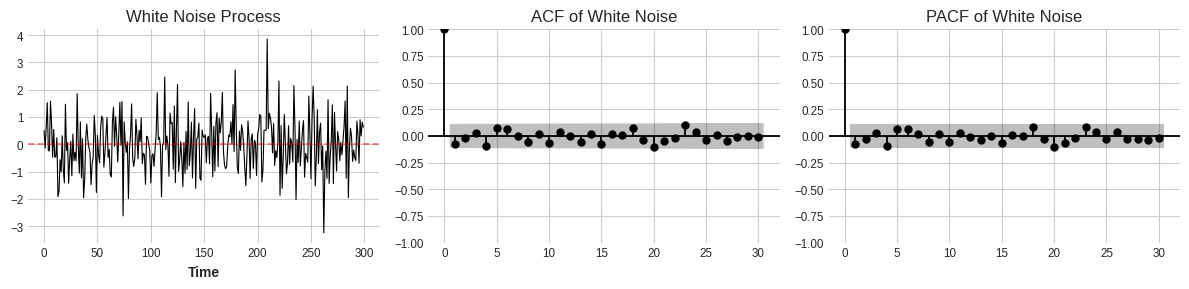

Mean: -0.0055 (theoretical: 0)
Variance: 0.9654 (theoretical: 1)


In [2]:
# Generate and visualize white noise
n = 300
white_noise = np.random.normal(0, 1, n)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Time series plot
axes[0].plot(white_noise, linewidth=0.8)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_title('White Noise Process')
axes[0].set_xlabel('Time')

# ACF
plot_acf(white_noise, ax=axes[1], lags=30, alpha=0.05)
axes[1].set_title('ACF of White Noise')

# PACF
plot_pacf(white_noise, ax=axes[2], lags=30, alpha=0.05)
axes[2].set_title('PACF of White Noise')

plt.tight_layout()
plt.show()

print(f"Mean: {np.mean(white_noise):.4f} (theoretical: 0)")
print(f"Variance: {np.var(white_noise):.4f} (theoretical: 1)")

The ACF and PACF of white noise show no significant correlations at any lag (all values fall within the confidence bands), confirming that there is no temporal structure to exploit for forecasting.

### 2.2. Autoregressive (AR) Models

An autoregressive model of order p, denoted AR(p), expresses the current value as a linear combination of its p most recent past values plus a white noise term:

$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \cdots + \phi_p Y_{t-p} + \varepsilon_t$$

where:

-   $c$ is a constant (related to the mean of the process)
-   $\phi_1, \phi_2, \ldots, \phi_p$ are the autoregressive coefficients
-   $\varepsilon_t$ is white noise with variance $\sigma^2$
-   $p$ is the order of the model

The term "autoregressive" reflects that $Y_t$ is regressed on its own past values.

#### 2.2.1. The AR(1) Process

The simplest autoregressive model is AR(1):

$$Y_t = c + \phi_1 Y_{t-1} + \varepsilon_t$$

Recall from Chapter 1 (Section 4.3) that the stability of the system depends entirely on the magnitude of the coefficient $\phi_1$. As we established:

-   If $\phi_1 = 1$: Random walk (non-stationary, unit root)
-   If $|\phi_1| > 1$: Explosive process (non-stationary)
-   If $|\phi_1| < 1$: Shocks decay over time (stationary process)

**Properties of stationary AR(1)**: While Chapter 1 introduced these properties assuming a zero mean, here we generalize them for a model with a constant intercept $c$:

-   Mean: $\mu = \frac{c}{1 - \phi_1}$
-   Variance: $\gamma_0 = \frac{\sigma^2}{1 - \phi_1^2}$
-   Autocorrelation at lag $h$: $\rho_h = \phi_1^h$

The autocorrelation decays exponentially, this is the signature pattern of AR processes.

![Comparison of AR(1) processes for different values of $\phi$](Figures/AR_1_comparison.png)

Key observations from AR(1):

-   Positive $\phi$: Smooth, persistent patterns. High values tend to be followed by high values.
-   Negative $\phi$: Oscillating pattern. High values tend to be followed by low values.
-   ACF: Decays exponentially (gradually) toward zero.
-   PACF: Cuts off sharply after lag 1 — this is how we identify AR(1).

#### 2.2.2. The AR(p) Process: General Case

For AR(p), the stationarity condition involves the characteristic polynomial:

$$\Phi(z) = 1 - \phi_1 z - \phi_2 z^2 - \cdots - \phi_p z^p$$

The process is stationary if and only if all roots of $\Phi(z) = 0$ lie outside the unit circle (i.e., $|z| > 1$).

Using the backshift operator $B$ where $B Y_t = Y_{t-1}; \ B^2 Y_t = Y_{t-2}; \ \ldots$, we can write AR(p) compactly as:

$$\Phi(B) Y_t = c + \varepsilon_t$$where $\Phi(B) = 1 - \phi_1 B - \phi_2 B^2 - \cdots - \phi_p B^p$.

![AR(2) process](Figures/AR_2.png)

**Identification rule for AR(p):** The PACF cuts off after lag p, while the ACF decays gradually (exponentially or with damped oscillations).

### 2.3. Moving Average (MA) Models

A moving average model of order q, denoted MA(q), expresses the current value as a linear combination of current and past white noise terms:

$$Y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \cdots + \theta_q \varepsilon_{t-q}$$

where:

-   $\mu$ is the mean of the process
-   $\theta_1, \theta_2, \ldots, \theta_q$ are the moving average coefficients
-   $\varepsilon_t, \varepsilon_{t-1}, \ldots$ are white noise terms
-   $q$ is the order of the model

**Important**: The "moving average" here in MA(q) is fundamentally different from the smoothing moving averages used in decomposition (Chapter 1). Here, we average random shocks, not observations.

Using the backshift operator:

$$Y_t = \mu + \Theta(B) \varepsilon_t$$

where $\Theta(B) = 1 + \theta_1 B + \theta_2 B^2 + \cdots + \theta_q B^q$.

#### 2.3.1. The MA(1) Process

The simplest moving average model is MA(1):

$$Y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1}$$

**Key properties**:

-   MA processes are always stationary (regardless of parameter values)
-   Mean: $E[Y_t] = \mu$
-   Variance: $\gamma_0 = \sigma^2(1 + \theta_1^2)$
-   Autocorrelation: $\rho_1 = \frac{\theta_1}{1 + \theta_1^2}$, and $\rho_h = 0$ for $h > 1$

**Visualizing the MA(1) Behavior**

Let's simulate two MA(1) processes with opposite signs for $\theta_1$ to observe their distinct behaviors and common identification patterns.

![MA(1) processes with different $\theta$ values](Figures/MA_1.png)

**Visual Interpretation MA(1):**

-   ACF (Correlogram): This is the signature of an MA process. Regardless of the sign of $\theta$, the autocorrelation is significant at lag 1 and then cuts off sharply to zero.
-   PACF: It decays gradually (either oscillating or exponentially), acting as the "echo" of the moving average. This is the opposite behavior of an AR process.
-   This pattern is the opposite of AR processes!

#### 2.3.2. Generalizing to MA(q): The MA(2) Example

Just as we saw with AR(p) models, the properties of the MA(1) extend to higher orders. An MA(q) process will show significant autocorrelations up to lag $q$, and zero thereafter, this is the signature of MA processes.

Let's verify this with an MA(2) process:

$$
Y_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2}
$$

![MA(2) Process](Figures/MA_2.png)

**Identification Rule:** For an MA(q) process, the theoretical ACF is non-zero for lags $h \leq q$ and zero for lags $h > q$. In the plot above, note how the significant spikes stop exactly after lag 2.

#### 2.3.3. Invertibility

Unlike AR models, which require parameter restrictions to be stationary, MA processes are stationary for any values of the parameters $\theta$. However, we face a critical problem regarding uniqueness and forecastability called invertibility.

**A. The Problem of Uniqueness** (Identifiability)

Consider an MA(1) process. Its autocorrelation at lag 1 is given by $\rho_1 = \frac{\theta_1}{1 + \theta_1^2}$.

Notice a mathematical curiosity: if we replace $\theta_1$ with $1/\theta_1$, the value of $\rho_1$ remains unchanged.

-   **Model A** ($\theta_1 = 0.5$):

    $\rho_1 = \frac{0.5}{1 + 0.25} = 0.4$

-   **Model B** ($\theta_1 = 2.0$):

    $\rho_1 = \frac{2.0}{1 + 4.0} = 0.4$

    Both models produce the exact same autocorrelation structure. Just by looking at the data (the ACF), it is impossible to distinguish whether the data came from Model A or Model B. To resolve this ambiguity, we adopt the convention of choosing the model where $|\theta_1| < 1$.

**B. The Problem of Forecastability** (The AR($\infty$) connection)

To forecast an MA model, we effectively need to invert it to express the current error $\varepsilon_t$ as a function of past observations ($Y_{t-1}, Y_{t-2}, \dots$). This is known as the $AR(\infty)$ representation.

$$Y_t = (1 + \theta_1 B)\varepsilon_t \implies \varepsilon_t = \frac{1}{(1 + \theta_1 B)} Y_t$$

Mathematically, the term $\frac{1}{(1 + \theta_1 B)}$ can be expanded as a geometric series $\sum_{k=1}^{\infty} (-\theta_1)^k B^k$. Therefore:

$$
Y_t = \sum_{k=1}^{\infty} - (-\theta)^k Y_{t-k}+\epsilon_k
$$

However, for this expansion to be valid (convergent), we strictly require $|\theta_1| < 1$.

-   If $|\theta_1| < 1$ (Invertible): The series converges. The weights of past observations decrease as we go further back in time ($-\theta, \theta^2, -\theta^3 \dots$). This makes logical sense: recent data is more important than distant data.
-   If $|\theta_1| > 1$ (Non-Invertible): The expansion on past values diverges mathematically (it is invalid). A valid expansion would essentially require weights on *future* values ($Y_{t+1}, Y_{t+2} \dots$), which makes the model useless for forecasting since we cannot observe the future.

**Formal Definition**

To ensure uniqueness and a valid representation based on past data, we impose the invertibility condition:

An MA(q) process is invertible if all roots of the characteristic polynomial lie outside the unit circle: $$\Theta(z) = 1 + \theta_1 z + \dots + \theta_q z^q \neq 0 \quad \text{for } |z| \leq 1$$

For a simple MA(1), this simplifies to the condition that $|\theta_1| < 1$.

### 2.4. ARMA Models

An ARMA(p, q) model combines both autoregressive and moving average components:

$$Y_t = c + \phi_1 Y_{t-1} + \cdots + \phi_p Y_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

Using the backshift operator, the ARMA model is usually written as:

$$\Phi(B) Y_t = c + \Theta(B) \varepsilon_t$$

**Conditions for validity**. To ensure the model is stable and has a unique representation, we require:

-   Stationarity: All roots of $\Phi(z) = 0$ outside the unit circle
-   Invertibility: All roots of $\Theta(z) = 0$ outside the unit circle

**Visual Example: ARMA(1,1)** Let's analyze an ARMA(1,1) process with $\phi_1=0.7$ and $\theta_1=0.4$.

![ARMA(1,1) Process with $\phi=0.7$ and $\theta=0.4$.](Figures/ARMA_1_1.png)

**Identification challenge**\
Unlike pure models, for an ARMA(p,q) process, both the ACF and PACF decay gradually. Neither cuts off sharply at a specific lag. This makes identifying the exact orders $(p, q)$ by visual inspection difficult. In practice, we rely on:

1.  Information Criteria: Use AIC (Akaike Information Criterion) or BIC to compare candidate models.

2.  Grid Search: Try multiple $(p, q)$ combinations.

3.  Automatic Selection: Use algorithms like `auto_arima` (discussed in Section 6).

### 2.5. Summary: ACF/PACF Patterns for Model Identification

| Model | ACF Pattern | PACF Pattern |
|:---|:---|:---|
| **AR(p)** | Decays gradually (exponential or damped sinusoidal) | Cuts off after lag p |
| **MA(q)** | Cuts off after lag q | Decays gradually |
| **ARMA(p,q)** | Decays gradually | Decays gradually |

These patterns provide the initial guidance for model selection, but final decisions should be based on:

1.  Information criteria (AIC, BIC)
2.  Residual diagnostics
3.  Out-of-sample forecasting performance

------------------------------------------------------------------------

## 3. ARIMA Models

Standard ARMA models rely on the assumption of weak stationarity. Recall from Chapter 1 that this implies three conditions: a constant mean, constant variance, and an autocovariance that depends only on the lag.

However, most real-world time series violate these conditions initially, often exhibiting non-constant variance (changing volatility or heteroscedasticity) and/or non-constant mean (trends or seasonal cycles).

Therefore, before applying ARMA models, we must transform the data to achieve stationarity. This brings us to the ARIMA (AutoRegressive Integrated Moving Average) framework.

### 3.1. Achieving Stationarity: Transformations and Differencing

To satisfy the stationarity requirement, we generally need to apply a sequence of transformations to the raw data. This process addresses the two main violations identified above—heteroscedasticity and trends—through two complementary steps:

1.  **Variance stabilization**: Apply a mathematical transformation to make the spread consistent across time.
2.  **Mean stabilization**: Apply differencing to remove trends and achieve a constant mean.

**Warning: The order matters**. We should stabilize the variance first, then apply differencing. This is because differencing a series with non-constant variance can produce unstable results, and the statistical tests to determine the differencing order assume homoskedasticity (constant variance).

#### 3.1.1. Variance-Stabilizing Transformations

Many time series exhibit heteroskedasticity: the variance changes over time, often increasing with the level of the series. This is common in economic and financial data, where larger values tend to have larger fluctuations.

![Time series exhibiting heteroscedasticity](Figures/3_3.1_heteroskedasticity.png)

##### The Logarithmic Transformation

The most common variance-stabilizing transformation is the natural logarithm:

$$W_t = \log(Y_t)$$

The log transformation is appropriate when:

-   All values are strictly positive ($Y_t > 0$)
-   The standard deviation is proportional to the mean (constant coefficient of variation)
-   The data spans several orders of magnitude
-   You suspect multiplicative seasonality or effects

**Why does it work?** This transformation is particularly effective when the volatility of the series increases proportionally with its level ($\sigma_t \propto \mu_t$). The logarithm compresses the scale of higher values more heavily than lower values. This "dampening" effect counteracts the expanding variance, resulting in a series with approximately constant spread.

A critical constraint is that logarithms are undefined for zero or negative numbers ($y_t \le 0$). That is because this transformation is only appropriate for strictly positive values. If the data contains such values, a common workaround is to apply a shifted logarithm:

$$
y_t' = \ln(y_t + \alpha)
$$

where $\alpha$ is a positive constant chosen to ensure the argument is strictly positive (typically $\alpha = |\min(y)| + 1$).

Additionally, the log transformation converts multiplicative relationships into additive ones:

$$Y_t = T_t \times S_t \times \varepsilon_t \quad \Rightarrow \quad \log(Y_t) = \log(T_t) + \log(S_t) + \log(\varepsilon_t)$$

This property is crucial because standard ARIMA models assume an additive structure. Therefore, applying a log transformation allows us to effectively model multiplicative series using linear techniques.

![](Figures/3_3.1.1_logTransformation.png)

##### The Box-Cox Transformation

While logarithms are useful, they are not always the optimal solution for stabilizing variance. A more general approach is the Box-Cox transformation, which represents a family of power transformations indexed by a parameter $\lambda$ (lambda).

The transformation is defined as: $$
W_t = \begin{cases}
\frac{Y_t^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\
\ln(Y_t) & \text{if } \lambda = 0
\end{cases}
$$

The parameter $\lambda$ controls the strength of the transformation. Different values correspond to standard transformations:

-   $\lambda = 1$: No transformation (linear).

-   $\lambda = 0.5$: Square root transformation (useful for count data).

-   $\lambda = 0$: Natural logarithm (as discussed above).

-   $\lambda = -1$: Inverse transformation ($1/Y_t$).

The main advantage of the Box-Cox method is that $\lambda$ does not need to be chosen arbitrarily; it can be optimized from the data. However, the optimization criteria depend on the goal:

1.  **Maximum Likelihood Estimation (MLE):** This is the default method in many Python packages (like `scipy.stats`). It searches for the $\lambda$ that makes the data distribution as close as possible to a Normal (Gaussian) distribution.

2.  **Guerrero Method:** In time series forecasting, our primary goal is variance stabilization, not necessarily normality. The Guerrero method (Guerrero, V. M. ,1993) is the standard technique for this. It selects the $\lambda$ that minimizes the coefficient of variation of the variance over different time periods (blocks), effectively ensuring the spread is constant throughout the series.

While the Guerrero method is the standard in statistical environments like R (e.g., the `forecast` package), standard Python libraries often lack this implementation, favoring MLE which aligns more with general statistical modeling and machine learning tasks. Therefore, to achieve optimal variance stabilization in Python, we often implement the Guerrero method manually.

The following code presents the `boxcox` implementation from the `scipy.stats` package and defines a custom Guerrero function to find the optimal \\lambda\$ that minimizes the coefficient of variation of the rolling variance.

In [3]:
import numpy as np
import pandas as pd
from scipy import stats

# -------------------------------------------------------------------------
# Custom Implementation of Guerrero's Method (Guerrero, V. M. ,1993)
# Goal: Find lambda that minimizes the Coefficient of Variation of the 
#       standard deviation over rolling windows.
# -------------------------------------------------------------------------
def guerrero_lambda(series, min_lambda=-2, max_lambda=2, window_size=24):
    """
    Estimates the optimal Box-Cox lambda using the Guerrero method.
    """
    series_clean = series.copy()
    # Box-Cox requires strictly positive data
    if series_clean.min() <= 0:
        series_clean += np.abs(series_clean.min()) + 1
        
    # lambdas = np.round(np.arange(min_lambda, max_lambda, 0.1), 1) # Search range
    lambdas = np.arange(min_lambda, max_lambda, 0.1) # Search range
    cvs = [] # To store Coefficient of Variation
    
    for l in lambdas:
        # Apply transformation
        if l == 0:
            trans_data = np.log(series_clean)
        else:
            trans_data = (series_clean**l - 1) / l
        
        # Calculate rolling standard deviation
        s_trans = pd.Series(trans_data)
        roll_std = s_trans.rolling(window_size).std()
        
        # Calculate CV of the rolling std (Spread of the spread)
        valid_std = roll_std.dropna()
        cv = valid_std.std() / valid_std.mean()
        cvs.append(cv)
    
    # Return lambda that minimizes the variation of variance
    return np.round(lambdas[np.argmin(cvs)],1)

In [4]:
from scipy.stats import boxcox, boxcox_normmax

np.random.seed(42)
n = 240
#####################################################
# Simulate a series where variance grows with level #
#####################################################
trend = np.linspace(100, 500, n)
# Variance proportional to level (coefficient of variation ~ constant)
noise = np.array([np.random.normal(0, 0.15 * trend[i]) for i in range(n)])
y_heteroscedastic = trend + noise
# Create date index
dates = pd.date_range('2005-01-01', periods=n, freq='MS')
series_hetero = pd.Series(y_heteroscedastic, index=dates)

## Apply Box-Cox transformation - Guerrero
# find optimal lambda (as fecuency is monthly, we use a 2 years rolling window)
lambda_guerrero = guerrero_lambda(series_hetero, window_size=24) 
series_boxcox_guerrero = boxcox(series_hetero, lmbda=lambda_guerrero)
print(f"Optimal Box-Cox λ - Guerrero: {lambda_guerrero:.1f}")

## Apply Box-Cox transformation - MLE
# find optimal lambda (as fequency is monthly, we use a 2 years rolling window)
series_boxcox_mle, lambda_mle = boxcox(series_hetero)
print(f"Optimal Box-Cox λ - MLE: {lambda_mle:.1f}")

Optimal Box-Cox λ - Guerrero: 0.0
Optimal Box-Cox λ - MLE: 0.5


![](Figures/3_3.1.1_BoxCoxTransformation.png){width="900"}

##### Practical Guidelines for Choosing a Transformation

1.  Visual inspection: Create a spread-level plot. A positive slope suggests transformation is needed.

2.  Use Box-Cox to guide your choice:

    -   If $\lambda \approx 1$: No transformation needed
    -   If $\lambda \approx 0$: Use log (simpler and more interpretable)
    -   If $\lambda \approx 0.5$: Use square root
    -   Otherwise: Use the Box-Cox transformation with the estimated $\lambda$

3.  Prefer simpler transformations: Log and square root are easier to interpret and back-transform. Only use Box-Cox with unusual $\lambda$ values if the improvement is substantial.

4.  Check the result: After transformation, the spread-level plot should show no relationship (flat slope)

##### Back-Transformation: Returning to the Original Scale

After fitting a model and generating forecasts in the transformed scale ($W_t$), we must back-transform the predictions to return to the original scale ($Y_t$) for interpretation and decision-making.

**Simple Back-Transformation (The Median Forecast)**

To obtain the point forecast on the original scale, we apply the inverse function of the transformation used.

-   For the Log transformation (Box-Cox with $\lambda = 0$): $$
      \hat{Y}_t = \exp(\hat{W}_t)
      $$

-   For the Box-Cox transformation ($\lambda \neq 0$): $$
      \hat{Y}_t = (\lambda \hat{W}_t + 1)^{1/\lambda}
      $$

The function `scipy.special.inv_boxcox(x, lambda)` allows for simple back-transformation for both cases (it automatically handles $\lambda=0$ as the exponential).

In [5]:
from scipy.special import inv_boxcox
import numpy as np

# ==============================================================================
# 1. SIMPLE BACK-TRANSFORMATION (Validation)
# ==============================================================================
# We verify that we can recover the original series using inv_boxcox.
# Note: inv_boxcox works for both lambda=0 (log) and lambda!=0 automatically.

# Reverting Guerrero Series
reverted_guerrero = inv_boxcox(series_boxcox_guerrero, lambda_guerrero)

# Reverting MLE Series
reverted_mle = inv_boxcox(series_boxcox_mle, lambda_mle)

# Verification check
print("Difference between Original and Reverted (Guerrero):")
print(np.mean(np.abs(series_hetero - reverted_guerrero))) # Should be close to 0

print("\nDifference between Original and Reverted (MLE):")
print(np.mean(np.abs(series_hetero - reverted_mle))) # Should be close to 0

Difference between Original and Reverted (Guerrero):
6.756077179185619e-14

Difference between Original and Reverted (MLE):
6.8508162106203e-14


**The Bias Adjustment (The Mean Forecast)**

There is a critical subtlety in this process: simply back-transforming the forecast ($\hat{W}_t$) yields the median of the forecast distribution, not the mean. While the median is a valid point forecast, the mean is often preferred in contexts like supply chain or finance because the sum of the means equals the mean of the sum (useful for aggregation), whereas medians do not sum up.

Because the transformation functions are non-linear, the mean of the transformed data does not equal the transformed mean of the data (Jensen's inequality). To obtain the mean forecast, a bias adjustment is required using the forecast variance ($\hat{\sigma}^2$):

-   For the Log transformation:\
    $$
      \hat{Y}_t = \exp\left(\hat{W}_t + \frac{\hat{\sigma}^2}{2}\right)
      $$

-   For the Box-Cox transformation: The exact mean is complex to calculate analytically. However, a standard Taylor series approximation is given by: $$
      \hat{Y}_t \approx (\lambda \hat{W}_t + 1)^{1/\lambda} \left( 1 + \frac{\hat{\sigma}^2 (1-\lambda)}{2(\lambda \hat{W}_t + 1)^2} \right)
      $$

Unfortunately, standard Python libraries (such as `scipy` or `statsmodels`) do not currently provide a built-in function for bias-adjusted back-transformation. While `inv_boxcox` is sufficient for the median, obtaining the mean forecast requires calculating the specific adjustment manually using the formulas provided above.

**Prediction Intervals**

For prediction intervals, no bias adjustment is needed. We simply back-transform the lower ($L_t$) and upper ($U_t$) bounds of the prediction interval calculated in the transformed scale using the simple inverse formulas above:

$$
\text{Lower: } f^{-1}(L_t), \quad \text{Upper: } f^{-1}(U_t)
$$

A key feature of these back-transformed intervals is that they will be asymmetric around the point forecast. This is a desirable property, as it correctly reflects that uncertainty in heteroscedastic data is often larger for higher values than for lower ones.

#### 3.1.2. Mean-Stabilizing Transformations: Differencing

Once variance is stabilized, we address non-constant mean through differencing. As introduced in Chapter 1, differencing removes trends by computing changes between consecutive observations.

##### Regular Differencing

The first difference operator $\nabla$ (or $(1-B)$ using the backshift operator) computes:

$$\nabla Y_t = Y_t - Y_{t-1} = (1-B)Y_t$$

This removes a linear trend. If the first difference still shows a trend, we can apply a second difference:

$$\nabla^2 Y_t = \nabla(\nabla Y_t) = Y_t - 2Y_{t-1} + Y_{t-2} = (1-B)^2 Y_t$$

The second difference removes a quadratic trend.

**Important**: Each difference loses one observation. After $d$ differences, we have $n-d$ observations remaining.

**How Many Differences?**

The goal is to achieve stationarity with the minimum number of differences. Over-differencing can introduce unnecessary complexity and spurious patterns.

Guidelines:

1.  Rarely need $d > 2$: If two differences don't achieve stationarity, consider whether a transformation was missed or whether the series has other issues.

2.  Visual inspection: Plot the differenced series. It should fluctuate around a constant mean with stable variance.

3.  ACF check: A stationary series has an ACF that decays quickly. A slowly decaying ACF suggests more differencing is needed.

4.  Statistical tests: Use ADF and KPSS tests on the differenced series.

5.  Variance rule: If differencing increases the variance substantially, you may have over-differenced.

![Differencing a Quadratic Trend Time Series](Figures/3_3.2_Differencing_quadraticTrend.png)

The previous figure illustrates why higher-order differencing is necessary for complex trends. The original series follows a quadratic curve ($t^2$). Applying the first difference ($d=1$) removes the curvature but leaves a distinct linear trend, as evidenced by the series' positive slope and the slow decay in the ACF. Stationarity is only achieved after the second difference ($d=2$), where the series oscillates around a constant mean and the ACF drops quickly to zero, confirming the removal of all trend components.

By contrast, the figure below demonstrates the detrimental effects of differencing beyond what is necessary. For a series with a linear trend, the first difference ($d=1$) is optimal, resulting in white noise with minimum variance. Applying further differences ($d=2$ and $d=3$) constitutes overdifferencing. This introduces two distinct problems: an unnecessary increase in variance (instability) and an artificial negative correlation at Lag 1 in the ACF plots, creating a false pattern of dependency where none exists.

![Differencing a Quadratic Trend Time Series](Figures/3_3.2_Overdifferencing_linearTrend.png){fig-alt="Overdifferencing a Linear Trend Time Series"}

**Differencing Time Series in Python**

Implementing differencing in Python is a straightforward process using standard data analysis libraries. It is worth noting that both `pandas` (`DataFrame` and `Series` objects) and `darts` (`TimeSeries` objects) share the same syntax for this operation: the `.diff()` method.

By default, the `.diff()` method, calculates the difference between the current observation and the previous one ($Y_t - Y_{t-1}$), although the `periods` argument can be adjusted for higher-order or seasonal differencing.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1. Load Data
# -----------------------------------------------------------------------------
file = './Data/differencing_exampleData.pkl'
# Load the pickle file directly
series = pd.read_pickle(file)

# -----------------------------------------------------------------------------
# 2. Apply Differencing
# -----------------------------------------------------------------------------
diff1 = series.diff().dropna()
diff2 = diff1.diff().dropna()

datasets = [
    ('Original Series', series, 'black'),
    ('1st Diff (d=1)', diff1, 'green'),
    ('2nd Diff (d=2)', diff2, 'red')
]

# -----------------------------------------------------------------------------
# 3. Compute Statistical Tests 
# -----------------------------------------------------------------------------
# Original Series
adf_orig = adfuller(series.dropna())[1]
kpss_orig = kpss(series.dropna(), regression='c', nlags="auto")[1]

# First Difference (d=1)
adf_d1 = adfuller(diff1)[1]
kpss_d1 = kpss(diff1, regression='c', nlags="auto")[1]

# Second Difference (d=2)
adf_d2 = adfuller(diff2)[1]
kpss_d2 = kpss(diff2, regression='c', nlags="auto")[1]

# -----------------------------------------------------------------------------
# 4. Visualization (Step-by-step)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# --- ROW 1: ORIGINAL SERIES ---
# Line Plot
axes[0, 0].plot(series, color='black')
axes[0, 0].set_title(f"Original Series\n(ADF p: {adf_orig:.4f} | KPSS p: {kpss_orig:.4f})", fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=series.mean(), color='blue', linestyle='--', alpha=0.5)

# ACF Plot
plot_acf(series, ax=axes[0, 1], lags=30, title='ACF - Original Series', zero=False)
axes[0, 1].grid(True, alpha=0.3)


# --- ROW 2: FIRST DIFFERENCE (d=1) ---
# Line Plot
axes[1, 0].plot(diff1, color='green')
axes[1, 0].set_title(f"1st Difference (d=1)\n(ADF p: {adf_d1:.4f} | KPSS p: {kpss_d1:.4f})", fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=diff1.mean(), color='blue', linestyle='--', alpha=0.5)

# ACF Plot
plot_acf(diff1, ax=axes[1, 1], lags=30, title='ACF - 1st Difference', zero=False)
axes[1, 1].grid(True, alpha=0.3)


# --- ROW 3: SECOND DIFFERENCE (d=2) ---
# Line Plot
axes[2, 0].plot(diff2, color='red')
axes[2, 0].set_title(f"2nd Difference (d=2)\n(ADF p: {adf_d2:.4f} | KPSS p: {kpss_d2:.4f})", fontweight='bold')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].axhline(y=diff2.mean(), color='blue', linestyle='--', alpha=0.5)

# ACF Plot
plot_acf(diff2, ax=axes[2, 1], lags=30, title='ACF - 2nd Difference', zero=False)
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './Data/differencing_exampleData.pkl'

##### Seasonal Differencing

Regular differencing removes trends, but many time series exhibit seasonality—patterns that repeat at fixed intervals $m$ (e.g., $m=12$ for monthly data, $m=4$ for quarterly). A series with strong seasonality is not stationary because its mean varies by season.

The Seasonal Difference OperatorTo remove seasonality, we subtract the observation from the same season in the previous cycle, rather than the immediately preceding observation:

$$\nabla_m Y_t = Y_t - Y_{t-m} = (1 - B^m)Y_t$$ For example, with monthly data ($m=12$), we subtract this January's value from last January's value.

While advanced identification methods (like PACF) will be covered in the SARIMA modeling chapter, a simple inspection of the ACF is often sufficient:

-   Visual Signal: If the ACF plot shows significant spikes at seasonal lags ($12, 24, 36\dots$), the series needs seasonal differencing.

-   Order: Usually, we apply seasonal differencing ($D=1$) first. If the trend remains, we then apply regular differencing ($d=1$).It is rare to need more than one seasonal difference ($D=1$).

In [ ]:
import pandas as pd
from statsmodels.datasets import co2

# -----------------------------------------------------------------------------
# 1. Load Data (Demonstration with both libraries)
# -----------------------------------------------------------------------------

# OPTION A: Using sktime
co2_data = co2.load_pandas().data
# Resample to Monthly start to handle missing values and match frequencies
co2_series = co2_data['co2'].resample('MS').mean().ffill()

series = co2_series

# -----------------------------------------------------------------------------
# 2. Apply Seasonal Differencing
# -----------------------------------------------------------------------------
# m = 12 (Monthly data)
# We subtract this month's value from the same month last year: (Yt - Yt-12)
# This is achieved by setting the 'periods' argument to 12.
seasonal_diff = series.diff(periods=12).dropna()

# -----------------------------------------------------------------------------
# 3. Apply Regular Differencing (Trend Removal)
# -----------------------------------------------------------------------------
# Often, removing seasonality reveals the underlying trend more clearly.
# To make the series truly stationary, we apply a regular difference (d=1) 
# on top of the seasonal difference.
# Mathematical operation: (1 - B)(1 - B^12)Yt
combined_diff = seasonal_diff.diff().dropna()

![](Figures/3_3.2_seasonalDifferencing.png)

Seasonal differencing

After applying seasonal differencing ($\nabla_{12}$) and regular differencing ($\nabla$), the time series should ideally exhibit stationarity—meaning a constant mean and variance. However, it is common to observe significant spikes in the ACF plot at seasonal lags (e.g., at $t=12$ for monthly data).

It is crucial to distinguish between stationarity and white noise:

1.  Stationarity: The series has been successfully "flattened"; trend and seasonal *levels* are removed.

2.  Correlation Structure: The remaining spikes indicate that the series is not yet random noise. The differencing process often induces a specific correlation structure at the seasonal lag.

For instance, a significant negative spike at lag 12 in the ACF of a differenced series is the characteristic signature of a Seasonal Moving Average (SMA) process. This does not imply that the differencing failed, but rather provides the necessary diagnostic information to select the appropriate SARIMA model parameters (specifically, the seasonal $Q$ term) in the subsequent modeling phase (Section 5).

#### 3.1.3. Exercise

Use the airline dataset and transform it to achieve stacionarity.

Instructions:

1.  Load the Data: Use the `sktime.datasets.load_airline` function to load the classic "Box-Jenkins Airline Passengers" dataset.

2.  Visual Diagnosis: Plot the original series. Does the variance (amplitude of the oscillations) remain constant over time, or does it increase with the trend?

3.  Variance Stabilization: If the variance is non-constant, apply the corresponding transformation to obtain homocedasticity.

4.  Mean Stabilization: Apply the necessary differencing operations

5.  Verification: Plot the final transformed series and its Autocorrelation Function (ACF). Confirm visually that the series oscillates around a constant mean with stable variance.

In [7]:
# Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sktime.datasets import load_airline

# Statistical modeling
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Forecasting libraries
from darts import TimeSeries
from darts.models import ARIMA as DartsARIMA

# Skforecast for backtesting
from skforecast.sarimax import Sarimax
from skforecast.recursive import ForecasterSarimax

# Configuration
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

In [8]:
import numpy as np
import pandas as pd
from scipy import stats

# -------------------------------------------------------------------------
# Custom Implementation of Guerrero's Method (Guerrero, V. M. ,1993)
# Goal: Find lambda that minimizes the Coefficient of Variation of the 
#       standard deviation over rolling windows.
# -------------------------------------------------------------------------
def guerrero_lambda(series, min_lambda=-2, max_lambda=2, window_size=24):
    """
    Estimates the optimal Box-Cox lambda using the Guerrero method.
    """
    series_clean = series.copy()
    # Box-Cox requires strictly positive data
    if series_clean.min() <= 0:
        series_clean += np.abs(series_clean.min()) + 1
        
    # lambdas = np.round(np.arange(min_lambda, max_lambda, 0.1), 1) # Search range
    lambdas = np.arange(min_lambda, max_lambda, 0.1) # Search range
    cvs = [] # To store Coefficient of Variation
    
    for l in lambdas:
        # Apply transformation
        if l == 0:
            trans_data = np.log(series_clean)
        else:
            trans_data = (series_clean**l - 1) / l
        
        # Calculate rolling standard deviation
        s_trans = pd.Series(trans_data)
        roll_std = s_trans.rolling(window_size).std()
        
        # Calculate CV of the rolling std (Spread of the spread)
        valid_std = roll_std.dropna()
        cv = valid_std.std() / valid_std.mean()
        cvs.append(cv)
    
    # Return lambda that minimizes the variation of variance
    return np.round(lambdas[np.argmin(cvs)],1)

<Axes: xlabel='Period'>

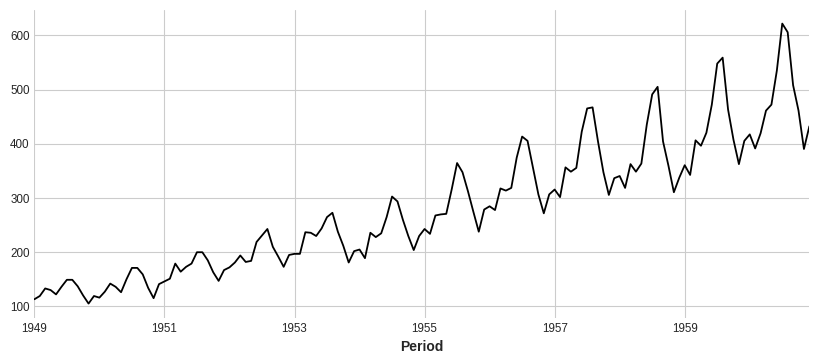

In [9]:
dataset = load_airline()
dataset.plot()

In [10]:
## Apply Box-Cox transformation - Guerrero
# find optimal lambda (as fecuency is monthly, we use a 2 years rolling window)
lambda_guerrero = guerrero_lambda(dataset, window_size=24) 
series_boxcox_guerrero = boxcox(dataset, lmbda=lambda_guerrero)
print(f"Optimal Box-Cox λ - Guerrero: {lambda_guerrero:.1f}")

## Apply Box-Cox transformation - MLE
# find optimal lambda (as fequency is monthly, we use a 2 years rolling window)
series_boxcox_mle, lambda_mle = boxcox(dataset)
print(f"Optimal Box-Cox λ - MLE: {lambda_mle:.1f}")

Optimal Box-Cox λ - Guerrero: 0.0
Optimal Box-Cox λ - MLE: 0.1


In [11]:
series_boxcox_guerrero = pd.Series(boxcox(dataset, lmbda=lambda_guerrero))

<Axes: >

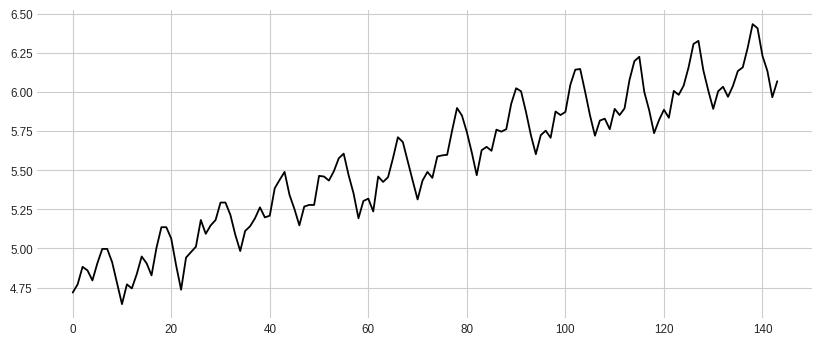

In [12]:
series_boxcox_guerrero.plot()

<Axes: >

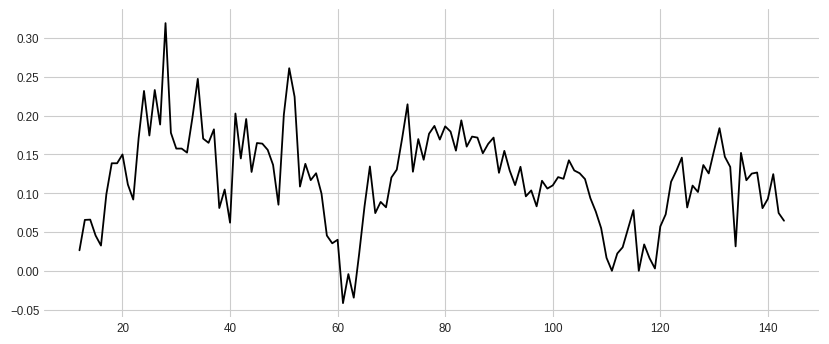

In [13]:
dataset_detrend = series_boxcox_guerrero.diff(periods=12).dropna()
dataset_detrend.plot()

<Axes: >

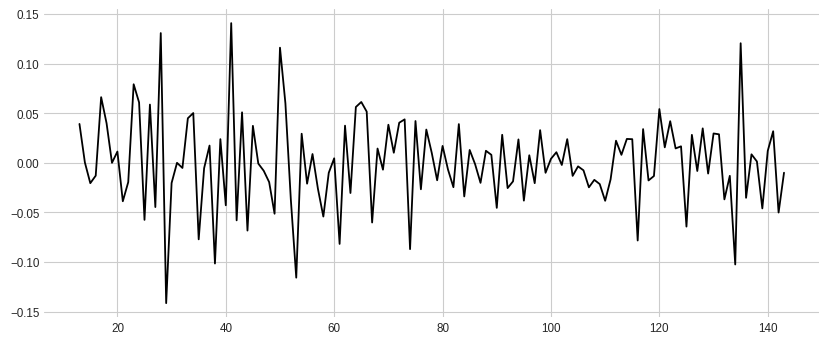

In [15]:
dataset_detrend_2 = dataset_detrend.diff(periods=1).dropna()
dataset_detrend_2.plot()

#### 3.2. The ARIMA(p, d, q) Model

An ARIMA(p, d, q) model combines Autoregression (AR) and Moving Average (MA) components with Differencing (Integration) to handle non-stationary series. It models the $d$-th difference of the series $Y_t$ as follows:

$$\Phi(B)(1-B)^d Y_t = c + \Theta(B) \varepsilon_t$$

Expanding this equation reveals the structure:

$$(1 - \phi_1 B - \cdots - \phi_p B^p)(1-B)^d Y_t = c + (1 + \theta_1 B + \cdots + \theta_q B^q) \varepsilon_t$$

**Parameters**:

-   $p$: Order of the autoregressive part
-   $d$: Degree of differencing (number of times the series is differenced)
-   $q$: Order of the moving average part

**Special cases**:

-   ARIMA(p, 0, 0) = AR(p)
-   ARIMA(0, 0, q) = MA(q)
-   ARIMA(p, 0, q) = ARMA(p, q)
-   ARIMA(0, 1, 0) = Random walk

#### 3.2.1. The Model Identification Workflow

The classical Box-Jenkins methodology for identifying an ARIMA model consists of four iterative steps:

**Step 1: Assess stationarity**

-   Visual inspection of the time series plot to identify trends or changing variance.
-   ACF plot: A slow, linear decay in the Autocorrelation Function indicates non-stationarity.
-   Statistical tests: Perform Augmented Dickey-Fuller (ADF) and KPSS tests.

**Step 2: Apply differencing if needed**

-   If the series is non-stationary, apply the first difference ($\nabla Y_t$).
-   Re-check stationarity.
-   It is rarely necessary to use $d > 2$.

**Step 3: Identify p and q from differenced series**

-   Examine the ACF and PACF of the differenced (stationary) series.
-   Use the signature patterns (cut-offs vs. decay) described in Section 2.5 to determine tentative orders.

**Step 4: Estimate and diagnose**

-   Fit the candidate model using Maximum Likelihood Estimation (MLE).
-   Analyze residuals: they should resemble white noise.
-   Compare models using Information Criteria (AIC/BIC).

Let's apply this workflow to the US Real GDP dataset. This series exhibits a strong trend due to economic growth but lacks the seasonal cycles seen in monthly sales data, making it ideal for standard ARIMA modeling.

Dataset: US Real GDP (Quarterly)
Period: 1959-01-01 to 2009-07-01
Number of observations: 203


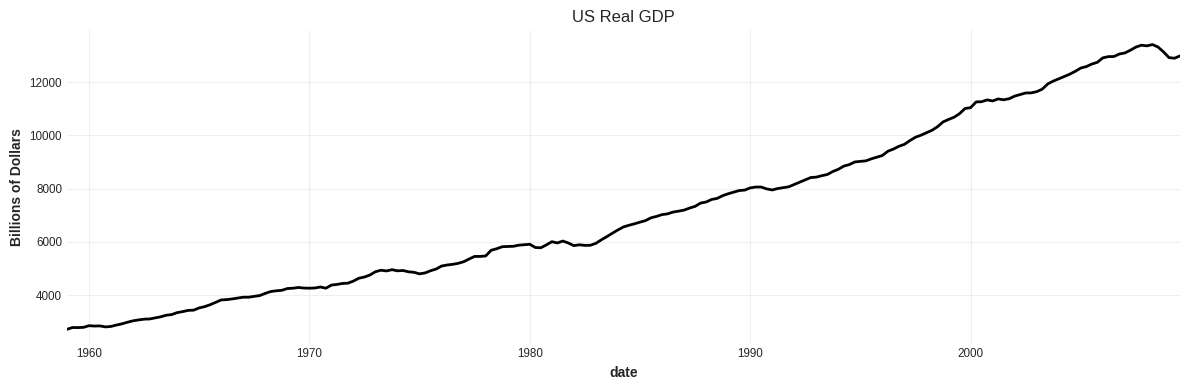

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# 1. Load Data: US Macroeconomic Data (1959-2009)
dataset = sm.datasets.macrodata.load_pandas()
data = dataset.data

# Create a proper DatetimeIndex combining Year and Quarter
data['date'] = (data['year'].astype(int).astype(str) + 
                'Q' + data['quarter'].astype(int).astype(str))
data.index = pd.PeriodIndex(data['date'], freq='Q').to_timestamp()

y = data['realgdp']
y.name = 'US Real GDP'

print(f"Dataset: US Real GDP (Quarterly)")
print(f"Period: {y.index.min().date()} to {y.index.max().date()}")
print(f"Number of observations: {len(y)}")

# 2. Plot the series
fig, ax = plt.subplots(figsize=(12, 4))
y.plot(ax=ax, linewidth=2, color='black')
ax.set_title('US Real GDP')
ax.set_ylabel('Billions of Dollars')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Step 1: Assess stationarity
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_report(series, name="Series"):
    """Generate a comprehensive stationarity report"""
    print(f"\n{'='*60}")
    print(f"Stationarity Analysis: {name}")
    print('='*60)
    
    # ADF Test
    # H0: Unit root exists (Non-stationary)
    try:
        adf_result = adfuller(series.dropna(), autolag='AIC')
        print(f"\nADF Test (H0: Non-stationary)")
        print(f"  Test Statistic: {adf_result[0]:.4f}")
        print(f"  p-value:        {adf_result[1]:.4f}")
        print(f"  >> Conclusion:  {'REJECT H0 (Stationary)' if adf_result[1] < 0.05 else 'FAIL TO REJECT H0 (Non-stationary)'}")
    except Exception as e:
        print(f"ADF Error: {e}")
    
    # KPSS Test
    # H0: Stationary
    try:
        kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
        print(f"\nKPSS Test (H0: Stationary)")
        print(f"  Test Statistic: {kpss_result[0]:.4f}")
        print(f"  p-value:        {kpss_result[1]:.4f}")
        print(f"  >> Conclusion:  {'REJECT H0 (Non-stationary)' if kpss_result[1] < 0.05 else 'FAIL TO REJECT H0 (Stationary)'}")
    except Exception as e:
        print(f"KPSS Error: {e}")

stationarity_report(y, "US Real GDP dataset")


Stationarity Analysis: US Real GDP dataset

ADF Test (H0: Non-stationary)
  Test Statistic: 1.7505
  p-value:        0.9982
  >> Conclusion:  FAIL TO REJECT H0 (Non-stationary)

KPSS Test (H0: Stationary)
  Test Statistic: 2.0685
  p-value:        0.0100
  >> Conclusion:  REJECT H0 (Non-stationary)


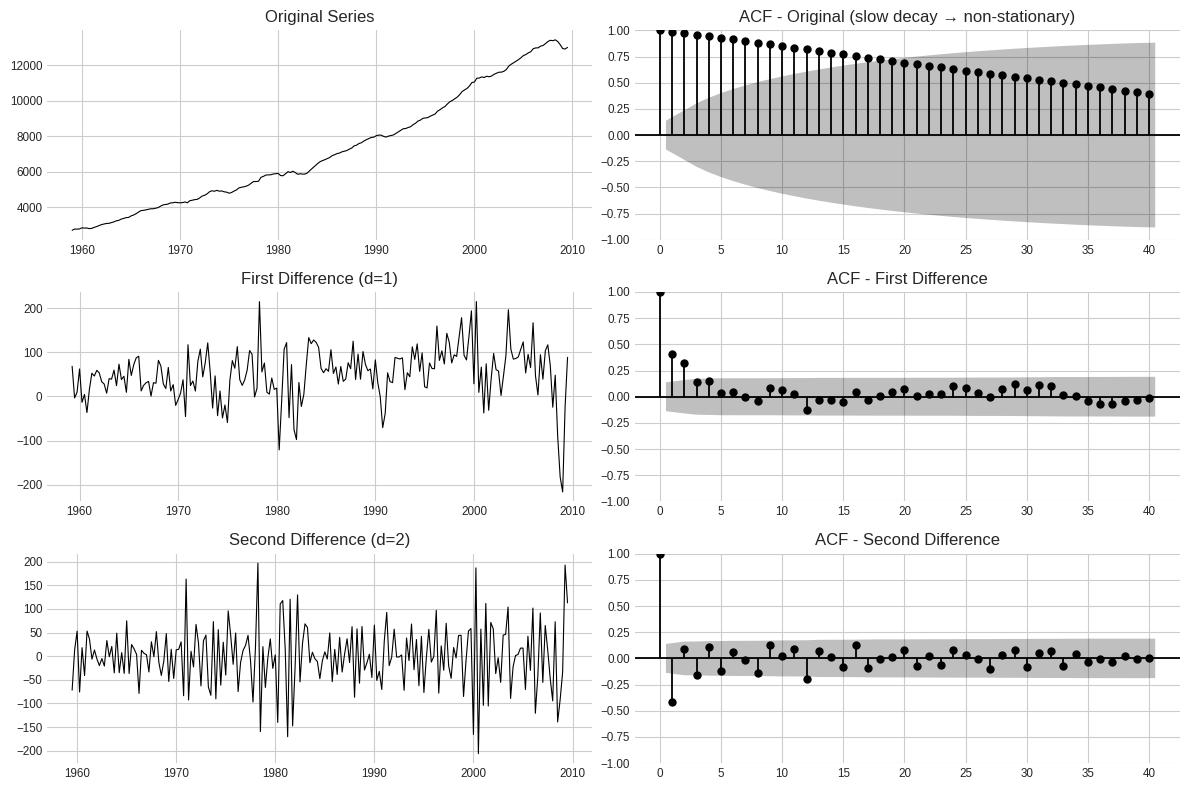


Stationarity Analysis: First Difference

ADF Test (H0: Non-stationary)
  Test Statistic: -6.3057
  p-value:        0.0000
  >> Conclusion:  REJECT H0 (Stationary)

KPSS Test (H0: Stationary)
  Test Statistic: 0.3986
  p-value:        0.0778
  >> Conclusion:  FAIL TO REJECT H0 (Stationary)


In [10]:
# Step 2: Apply differencing
y_diff1 = y.diff().dropna()
y_diff2 = y_diff1.diff().dropna()

# Visual comparison
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

# Original series
axes[0, 0].plot(y, linewidth=0.8)
axes[0, 0].set_title('Original Series')
plot_acf(y, ax=axes[0, 1], lags=40, alpha=0.05)
axes[0, 1].set_title('ACF - Original (slow decay → non-stationary)')

# First difference
axes[1, 0].plot(y_diff1, linewidth=0.8)
axes[1, 0].set_title('First Difference (d=1)')
plot_acf(y_diff1, ax=axes[1, 1], lags=40, alpha=0.05)
axes[1, 1].set_title('ACF - First Difference')

# Second difference
axes[2, 0].plot(y_diff2, linewidth=0.8)
axes[2, 0].set_title('Second Difference (d=2)')
plot_acf(y_diff2, ax=axes[2, 1], lags=40, alpha=0.05)
axes[2, 1].set_title('ACF - Second Difference')

plt.tight_layout()
plt.show()

# Test stationarity of differenced series
stationarity_report(y_diff1, "First Difference")

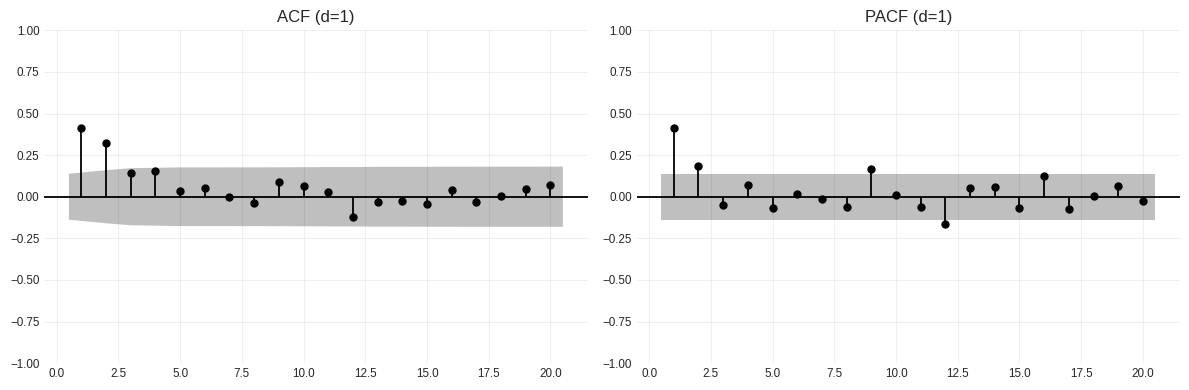

In [11]:
# Step 3: Identify p and q from the differenced series
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACF of d=1
# Note: We use y_diff1, which was defined in the previous cell
plot_acf(y_diff1, ax=axes[0], lags=20, alpha=0.05, title='ACF (d=1)', zero=False)
axes[0].grid(True, alpha=0.3)

# PACF of d=1
plot_pacf(y_diff1, ax=axes[1], lags=20, alpha=0.05, title='PACF (d=1)', zero=False)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

To identify the appropriate orders $p$ and $q$, we analyze the correlation patterns:

-   ACF: Displays significant spikes at lags 1 and 2, followed by a sharp cutoff. This behaviour could indicate an MA(2) component, but mixed with the PACF, it suggests a more complex structure.

-   PACF: Similarly shows a significant spike at lag 1 (and marginally at lag 2) before cutting off, characteristic of an AR process.

When both ACF and PACF trail off or show significant spikes at low lags without a clear geometric decay in one and a cutoff in the other, it typically indicates a mixed ARMA process or a low-order AR/MA model. Based on this visual inspection, we identify three strong candidate models to test: ARIMA(1,1,1), ARIMA(2,1,0), and ARIMA(0,1,2).

#### 3.2.2. Fitting ARIMA Models in Python

Once we have identified the candidate orders (p, d, q) —in our case, ARIMA(1,1,1)— the next step is to estimate the model parameters using Maximum Likelihood Estimation (MLE).

We will use the `statsmodels` library, which is the standard in Python for statistical inference. It provides the most detailed summary of the model's internal mechanics, which is crucial for the diagnostic phase.

In [12]:
from statsmodels.tsa.arima.model import ARIMA

# Fit the ARIMA(1,1,1) model derived from our manual identification
# Note: We pass the original series 'y'. Since order=(1,1,1) includes d=1,
# statsmodels handles the differencing internally.
model_sm = ARIMA(y, order=(1, 1, 1)) 
results_sm = model_sm.fit()

print(results_sm.summary())

                               SARIMAX Results                                
Dep. Variable:            US Real GDP   No. Observations:                  203
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1098.810
Date:                Thu, 19 Feb 2026   AIC                           2203.620
Time:                        16:42:15   BIC                           2213.545
Sample:                    01-01-1959   HQIC                          2207.636
                         - 07-01-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9343      0.031     30.516      0.000       0.874       0.994
ma.L1         -0.5896      0.056    -10.554      0.000      -0.699      -0.480
sigma2      3095.1442    256.779     12.054      0.0

**Understanding the Output:**

The summary table is divided into three main sections. While we will perform a deep dive into model evaluation in the next section, here is how to interpret the structure:

1.  Model Fit Statistics (Top Right):This section reports fitting metrics such as Log Likelihood, AIC, and BIC which are used to compare the quality of different models. The definition and usage of these criteria are covered in detail in Section 3.2.3 A.

2.  Coefficients Table (Middle):

    -   coef: The estimated values for the parameters: constant (if included), $\phi$ (`ar.L1`), and $\theta$ (`ma.L1`).

    -   P\>\|z\| (p-value): For each separate parameter, it tests the null hypothesis ($H_0$) that the coefficient is equal to zero (has no effect) against the alternative ($H_1$) that it is different from zero. A low p-value ($< 0.05$) indicates strong evidence against the null hypothesis, leading us to conclude that the coefficient is significantly different from zero and contributes meaningfully to the model.

3.  Residual Tests (Bottom): This section provides a preliminary check on the residuals, including the Ljung-Box test (for autocorrelation) and Jarque-Bera test (for normality). These diagnostic tools are further described in Section 3.2.3 B.

In this section, we manually specified the order `(1,1,1)`. In practice, especially with large datasets, we often use algorithms to search for the optimal order automatically. We will cover Auto-ARIMA (using the `pmdarima` library) and Grid Search strategies in Section 6. For now, it is critical to understand the manual process to interpret what the automatic tools provide. `pmdarima`, while best known for its `auto_arima` functionality, also implements a standard `ARIMA` class to fit specific models (e.g., fixed $(p,d,q)$ orders). It offers a `scikit-learn`-compatible interface (`fit`/`predict`), facilitating integration into standard ML pipelines. On the other hand, `darts` acts as a high-level wrapper that relies on `pmdarima` and `statsmodels`. It homogenizes the syntax to work with classical statistical models using the same API as other machine learning and deep learning models used in advanced time series forecasting.

In [13]:
import pmdarima as pm
from darts import TimeSeries
from darts.models import ARIMA as DartsARIMA
import matplotlib.pyplot as plt

# 1. Convert pandas Series to darts TimeSeries object
# This is a mandatory step for any model in the darts library
y_darts = TimeSeries.from_series(y)



# 2. Instantiate the model with specific parameters
# Note: Darts passes these parameters down to statsmodels/pmdarima
model_pm = pm.ARIMA(order=(1, 1, 1))
model_darts = DartsARIMA(p=1, d=1, q=1)

# 3. Fit the model
model_pm.fit(y)
model_darts.fit(y_darts)

# 4. Generate Forecasts
forecast_pm = model_pm.predict(n=8)
forecast_darts = model_darts.predict(n=8)

# 5. Visualization Comparison
fig, ax = plt.subplots(figsize=(10, 4))

# plot only 30 last observations for clarity
y_darts[-30:].plot(label='History (US GDP)')
# Plot pmdarima (solid line, painted first)
forecast_pm.plot(ax=ax, label="pmdarima", color="green")
# Plot darts (dashed line)
forecast_darts.plot(ax=ax, label="darts", color="blue", linestyle="--")
plt.title('US GDP Forecast (Zoomed)')
plt.legend()
plt.show()

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

#### 3.2.3. Model Evaluation and Diagnostics

After fitting a model, we need to evaluate whether it's a good choice. This involves two complementary approaches:

1.  Model selection criteria (AIC, BIC): Compare competing models to choose the best specification
2.  Residual diagnostics: Verify that the chosen model adequately captures the data structure

##### A Model Selection Criteria: AIC and BIC

The model summary displays AIC and BIC. These are *information criteria* used to compare competing models.

**The Fundamental Trade-off: Fit vs. Complexity**

When building statistical models, we face a fundamental tension:

-   More complex models (more parameters) fit the training data better
-   But overly complex models overfit: they capture noise rather than signal, leading to poor forecasts

Information criteria formalize this trade-off by penalizing model complexity.

**Likelihood: Measuring Model Fit**

Given a model with parameters $\theta$ and observed data $Y$, the likelihood $L(\theta|Y)$ measures how probable the observed data would be if this model were true.

-   Higher likelihood = the model explains the data better
-   We typically work with log-likelihood $\ell = \log(L)$ for numerical stability
-   Maximum Likelihood Estimation (MLE) finds parameters that maximize $\ell$

In the statsmodels output, `Log Likelihood` shows this value. A less negative (closer to zero) log-likelihood indicates better fit.

**Akaike Information Criterion (AIC)**

Introduced by Hirotugu Akaike in 1974, the AIC is defined as:

$$\text{AIC} = -2\ell + 2k$$

In this formula, $\ell$ represents the log-likelihood (model fit) and $k$ denotes the number of estimated parameters (model complexity). The first term ($-2\ell$) assesses the lack of fit; a lower value is preferable as it indicates a stronger fit. The second term ($2k$) serves as a penalty for model complexity, where each parameter adds two points to the overall score. Consequently, a lower AIC indicates a superior model fit.The AIC estimates the relative information lost when a model is used to approximate reality. Rooted in information theory, it asymptotically identifies the model best suited for predicting new data generated by the same process.

**Bayesian Information Criterion (BIC)**

Proposed by Gideon Schwarz in 1978, the BIC is calculated as:

$$\text{BIC} = -2\ell + k \log(n)$$

where $\ell$ represents the log-likelihood function, $k$ is the number of estimated parameters, and $n$ denotes the number of observations.

While it shares the same lack-of-fit term as the AIC, the BIC imposes a stricter penalty for model complexity: $k \log(n)$ instead of $2k$. Consequently, for sample sizes where $n > 7$, the BIC penalizes complexity more heavily than the AIC. As with the previous criterion, a lower BIC indicates a better-fitting model.The BIC is rooted in Bayesian probability and is designed to asymptotically select the "true" model, provided it is included among the candidate models.

**Comparing AIC and BIC**

| Aspect             | AIC                            | BIC                    |
|:-------------------|:-------------------------------|:-----------------------|
| Complexity Penalty | $2k$                           | $k \log(n)$            |
| Philosophy         | Best prediction                | True model selection   |
| Tendency           | May select more complex models | Prefers simpler models |
| Sample size effect | Constant penalty               | Penalty grows with $n$ |

Which metric should be use?

-   **AIC** is generally used when the primary goal is forecasting and the objective is a balanced trade-off between fit and complexity without excessively penalizing additional parameters. The AIC often selects slightly more complex models than the BIC and is a frequent choice when assuming that the "true" model is not necessarily among the candidates.
-   **BIC** is preferred when the goal is model identification or selection and a more parsimonious (simpler) model is desired, particularly with large sample sizes. Because the BIC applies a stricter penalty for complexity, it tends to prevent overfitting and favors model interpretability.

In practice, for forecasting purposes, the AIC is usually preferred, though it is common to use both to see if they converge on the same conclusion.

**Practical Example**

In [ ]:
# Compare models using AIC and BIC
from statsmodels.tsa.arima.model import ARIMA

# Fit several candidate models
models_to_compare = {
    'ARIMA(1,1,0)': (1,1,0),
    'ARIMA(0,1,1)': (0,1,1),
    'ARIMA(1,1,1)': (1,1,1),
    'ARIMA(2,1,1)': (2,1,1),
    'ARIMA(1,1,2)': (1,1,2),
    'ARIMA(2,1,2)': (2,1,2),
}

results = []
for name, order in models_to_compare.items():
    try:
        model = ARIMA(y, order=order)
        fit = model.fit()
        results.append({
            'Model': name,
            'k': fit.df_model + 1,
            'Log-Lik': round(fit.llf, 2),
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2)
        })
    except:
        pass

comparison = pd.DataFrame(results)
comparison = comparison.sort_values('AIC').reset_index(drop=True)

print("Model Comparison")
print("="*65)
print(comparison.to_string(index=False))
print(f"\nBest by AIC: {comparison.iloc[0]['Model']}")
print(f"Best by BIC: {comparison.sort_values('BIC').iloc[0]['Model']}")

**Important Limitations**

1.  **Same data required**: AIC/BIC can only compare models fitted on exactly the same data. This means:

    -   Cannot compare models with different differencing order $d$ (they're fitted on different transformed series)
    -   Cannot compare if different observations are missing

2.  **Relative, not absolute**: A low AIC doesn't mean the model is *good*, only that it's *better than alternatives*. All candidates could be poor fits. For forecasting quality evaluation, backtesting (Chapter 2 - Section 6) provides more relevant information.

3.  **Evaluating** $\Delta\text{AIC}$ : AIC is a random variable dependent on the specific sample observed. Small differences are often due to sampling noise rather than true model superiority. Standard rules of thumb (Burnham & Anderson, 2002) suggest:

    -   $\Delta\text{AIC} < 2$: Substantial empirical support for both models. The difference is so small (comparable to the penalty of a single parameter) that models are effectively indistinguishable.

    -   $\Delta\text{AIC} \in [4, 7]$: Considerably less support for the model with higher AIC.

    -   $\Delta\text{AIC} > 10$: Essentially no support for the worse model. It is extremely unlikely to be the best approximation among the candidates. Therefore, the worse model can be discarded.

##### B. Residual Analysis (Diagnostic Checking)

While information criteria (AIC/BIC) are effective for ranking competing models, they provide only a measure of *relative quality*. A model can be the "best" among a set of poor candidates and still fail to adequately capture the data's dynamics.

Therefore, we must validate the model's absolute adequacy. As detailed in Chapter 2, Section 3, residuals are defined as the difference between the observations and the corresponding fitted values ($e_{t} = y_{t} - \hat{y}_{t|t-1}$). The fundamental premise of ARIMA modeling is that if the model is well-specified, it should capture all the systematic information (signal), leaving behind only White Noise.

If patterns are observable in the residuals (or *innovation residuals* in the case of transformed data), the model implies that there is still extractable information that has been missed.

**Diagnostic Checklist**

To confirm the model is valid, the residuals must satisfy the properties of white noise and good forecasting errors defined in Section 3 of Chapter 2:

-   Zero Mean: The residuals should be centered around zero; otherwise, the forecasts are biased.

-   Uncorrelated: There should be no significant correlation between residual terms. If correlations exist, there is information left in the residuals.

-   Constant Variance (Homoscedasticity): The volatility of the errors should be constant over time.

-   Normality: Ideally, residuals should follow a Normal distribution. This is particularly useful for calculating accurate prediction intervals.

**Visual Diagnostic Tools**

To facilitate the model validation phase, time series libraries offer integrated diagnostic utilities to assessment residual properties. Packages such as `statsmodels`, `pmdarima`, and `darts` provide dedicated functions to automatically generate composite diagnostic panels. These standard outputs typically aggregate standardized residuals, spectral density estimates (histograms), normal Q-Q plots, and autocorrelation functions (ACF), ensuring a consistent, efficient, and rigorous evaluation of the model's statistical assumptions.

In [ ]:
import matplotlib.pyplot as plt
# ==============================================================================
# OPTION 1: Using statsmodels (Standard Approach)
# ==============================================================================
# The .plot_diagnostics() method generates the standard 4-plot panel:
# 1. Residuals over time
# 2. Histogram vs Normal Distribution (KDE)
# 3. Normal Q-Q Plot
# 4. Correlogram (ACF)
print("Diagnostic Plots (statsmodels):")
results_sm.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# OPTION 2: Using pmdarima
# ==============================================================================
# pmdarima wraps statsmodels, so it offers the exact same interface
# model_pm is the model fitted in the previous section
print("Diagnostic Plots (pmdarima):")
model_pm.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [ ]:
from darts.utils.statistics import plot_residuals_analysis
# ==============================================================================
# OPTION 3: Using darts
# ==============================================================================
# Darts provides a specific utility function for this purpose.
# First, we compute the residuals (Target - Forecast)
residuals_darts = model_darts.residuals(y_darts)

print("Diagnostic Plots (darts):")
# plot_residuals_analysis generates:
# 1. Residuals time plot
# 2. ACF
# 3. Histogram
plot_residuals_analysis(residuals_darts)
plt.show()

**Formal Hypothesis Tests**

While visual inspection provides a quick intuition, it remains subjective. To rigorously validate the model, we employ statistical tests to determine if the residuals truly satisfy the assumptions of independence and normality.

1.  Testing for Autocorrelation: The Ljung-Box Test (see Chapter 2 Section 3.1) evaluates the joint hypothesis that the residuals are independently distributed up to a specified lag. Ideally, we want to fail to reject the null hypothesis.

    -   $H_0$ (Null Hypothesis): The data are independently distributed (i.e., the residuals are White Noise).

    -   $H_1$ (Alternative Hypothesis): The data exhibit serial correlation (the model has failed to capture some signal).

    -   Interpretation: A large p-value ($> 0.05$) indicates that we cannot reject the null hypothesis, suggesting the residuals behave effectively like white noise.

2.  Testing for Normality: The Jarque-Bera Test checks if the residuals match the skewness and kurtosis expected of a normal distribution. While not strictly necessary for point forecasting, normality is crucial for generating accurate prediction intervals.

    -   $H_0$ (Null Hypothesis): The residuals follow a Normal distribution.

    -   $H_1$ (Alternative Hypothesis): The residuals do not follow a Normal distribution.

    -   Interpretation: A large p-value ($> 0.05$) suggests the residuals are consistent with a Gaussian (normal) distribution.

It is important to note that the standard `statsmodels` summary table (discussed in Section 3.2.2) already includes these diagnostics under the labels `Prob(Q)` (for Ljung-Box) and `Prob(JB)` (for Jarque-Bera). However, performing these tests explicitly is possible and allows for greater control, such as testing specific lag orders or extracting the values programmatically.

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

residuals = results_sm.resid
# 1. Ljung-Box Test (Autocorrelation)
# We test at lag 10 to check for short-term patterns
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
lb_pvalue = lb_test['lb_pvalue'].values[0]

# 2. Jarque-Bera Test (Normality)
jb_score, jb_pvalue, skew, kurtosis = jarque_bera(residuals)

print("Formal Diagnostic Tests")
print("-" * 30)
print(f"Ljung-Box p-value:  {lb_pvalue:.4f}")
print(f"Jarque-Bera p-value:{jb_pvalue:.4f}")

**Interpreting Diagnostic Results (Troubleshooting)**

When a diagnostic validation reveals a violation of model assumptions (whether through visual inspection or formal hypothesis testing) the specific characteristics of the observed anomalies typically inform the necessary model refinement. The following table delineates common diagnostic issues and prescribes the corresponding remedial strategies for ARIMA specification:"

|  |  |  |
|----|----|----|
| **Observation** | **Possible Cause** | **Solution** |
| ACF spikes at early lags | AR/MA order too low | Increase $p$ or $q$. |
| ACF spikes at seasonal lags | Seasonality not captured | Switch to SARIMA (add seasonal terms). |
| Variance changes over time | Heteroskedasticity | Apply Log or Box-Cox transformation (Section 3.1.1). |
| Residuals not Normal | Outliers or heavy tails | Check for outliers; standard forecasts may be risky. |
| Trend in residuals | Trend not removed | Increase differencing ($d$). |

------------------------------------------------------------------------

## 4. Seasonal ARIMA (SARIMA) Models

In Chapter 1, we learned to identify seasonality as a repeating pattern with a fixed frequency $m$ (e.g., every 12 months). In Section 3.1.2, we saw how seasonal differencing ($\nabla_m$) effectively removes these cycles to achieve stationarity.

However, simply removing the cycle is not enough; we want to model it. Just as the value of $Y_t$ typically depends on $Y_{t-1}$ (autoregression), in a seasonal series, the value for a given month is often heavily dependent on the value from the same month in the previous year ($Y_{t-12}$).

The SARIMA (Seasonal ARIMA) model extends the ARIMA framework to capture these relationships explicitly. It essentially fits two distinct components simultaneously:

1.  Non-Seasonal part $(p, d, q)$: Captures short-term correlations (e.g., relationships between consecutive months).

2.  Seasonal part $(P, D, Q)_m$: Captures long-term periodic correlations (e.g., relationships between the same month across different years).

### 4.1. Seasonal Patterns in ACF/PACF

The ACF plot serves as the principal diagnostic for detecting seasonal components. Whereas non-seasonal processes are characterized by a swift decay in correlations, seasonal data manifests periodic significant spikes at lags corresponding to the seasonal frequency $m$.

**Example**

Let's analyze a monthly dataset of fuel consumption. Since it is monthly data, we expect $m=12$.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from skforecast.datasets import fetch_dataset

# 1. Load Data
# We use a dataset with clear annual seasonality
data_fuel = fetch_dataset(name='fuel_consumption', raw=True)
data_fuel = data_fuel[['Fecha', 'Gasolinas']]
data_fuel = data_fuel.rename(columns={'Fecha': 'date', 'Gasolinas': 'consumption'})
data_fuel['date'] = pd.to_datetime(data_fuel['date'], format='%Y-%m-%d')
data_fuel = data_fuel.set_index('date').asfreq('MS')

# Select a training period
y_fuel = data_fuel['consumption'].loc[:'1990-01-01']

# 2. Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Time Series Plot
axes[0, 0].plot(y_fuel, color='black', linewidth=1)
axes[0, 0].set_title('Monthly Fuel Consumption')
axes[0, 0].grid(True, alpha=0.3)

# Seasonal Plot (Average by Month)
monthly_avg = y_fuel.groupby(y_fuel.index.month).mean()
axes[0, 1].bar(range(1, 13), monthly_avg.values, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Average Consumption by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_xticks(range(1, 13))

# ACF
plot_acf(y_fuel, ax=axes[1, 0], lags=48, alpha=0.05)
# Highlight seasonal lags (12, 24, 36)
for lag in [12, 24, 36, 48]:
    axes[1, 0].axvline(x=lag, color='red', linestyle='--', alpha=0.6)
axes[1, 0].set_title('ACF - Note the "Echoes" at lags 12, 24, 36...')

# PACF
plot_pacf(y_fuel, ax=axes[1, 1], lags=48, alpha=0.05)
# Highlight seasonal lags (12, 24, 36)
for lag in [12, 24, 36, 48]: # <--- Faltaba esta línea
    axes[1, 1].axvline(x=lag, color='red', linestyle='--', alpha=0.6)
axes[1, 1].set_title('PACF')

plt.tight_layout()
plt.show()

The ACF plot (bottom-left) fails to decay immediately, displaying prominent spikes at multiples of the seasonal lag (12, 24, 36, etc.). This indicates a high degree of correlation between observations and their corresponding values in previous years, confirming the requirement for a seasonal modeling approach.

### 4.2. The SARIMA Model

The SARIMA model is formally denoted as ARIMA$(p,d,q) \times (P,D,Q)_m$. The notation reflects the multiplicative interaction between the seasonal and non-seasonal polynomials.

The general mathematical formulation is given by:

$$
\underbrace{\Phi_p(B)}_{\text{Non-Seas AR}} \underbrace{\Phi_P(B^m)}_{\text{Seasonal AR}} (1-B)^d (1-B^m)^D Y_t = c + \underbrace{\Theta_q(B)}_{\text{Non-Seas MA}} \underbrace{\Theta_Q(B^m)}_{\text{Seasonal MA}} \varepsilon_t
$$

This equation comprises four distinct polynomials and two differencing operators:

1.  **Non-Seasonal Orders** $(p, d, q)$: Govern the short-term dynamics.

    -   $\Phi_p(B)$: Autoregressive polynomial of order $p$.

    -   $\Theta_q(B)$: Moving average polynomial of order $q$.

    -   $(1-B)^d$: Regular differencing operator of order $d$.

2.  **Seasonal Orders** $(P, D, Q)_m$: Govern the seasonal dynamics at frequency $m$.

    -   $\Phi_P(B^m)$: Seasonal AR polynomial. If $P=1$, $Y_t$ is regressed on $Y_{t-m}$.

    -   $\Theta_Q(B^m)$: Seasonal MA polynomial. If $Q=1$, the current error includes a component of the error observed $m$ periods ago ($\varepsilon_{t-m}$).

    -   $(1-B^m)^D$: Seasonal differencing operator (see Section 3.1.2) .

### 4.3. Identification Strategy

Model identification involves determining the appropriate integer values for seven distinct parameters: $(p, d, q)$ and $(P, D, Q)_m$. This process typically follows a sequential approach, distinguishing between the induction of stationarity and the modeling of autocorrelation.

**Step 1:** Assessment of Stationarity (Determining $d$ and $D$). The primary objective is to transform the observed series into a stationary process.

1.  Seasonal Stationarity: If the series exhibits a persistent seasonal pattern or a seasonal trend, a seasonal difference should be applied ($D=1$).

2.  Trend Stationarity: If the series remains non-stationary due to a lingering trend after seasonal differencing, regular differencing should be implemented ($d=1$).

In practical applications, values of $D > 1$ or $d > 1$ are rarely necessary and should be avoided to prevent over-differencing.

In [ ]:
# Apply seasonal differencing (D=1)
y_diff12 = y_fuel.diff(12).dropna()

# Apply first differencing (d=1) to the result
y_diff12_1 = y_diff12.diff(1).dropna()

# Visualization of transformed series
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

y_fuel.plot(ax=axes[0], title='Original Series')
y_diff12.plot(ax=axes[1], title='After Seasonal Differencing (D=1)')
y_diff12_1.plot(ax=axes[2], title='After Seasonal + First Differencing (D=1, d=1)')

plt.tight_layout()
plt.show()

# Verification via stationarity tests (function defined in Section 3.2.1)
stationarity_report(y_diff12_1, "Doubly Differenced Series")

**Step 2**: Order Selection ($P, Q$) and ($p, q$). Upon achieving stationarity (here, using D=1 and d=1), the ACF and PACF of the transformed series are analyzed. The identification involves inspecting the correlograms at two distinct time scales:

1.  Seasonal Scale (Lags $m, 2m, 3m...$): Observations at lags $m$, $2m$, $3m$ determine the seasonal orders $P$ and $Q$.

2.  Short-term Scale (Lags 1, 2, 3...): Observations at early lags determine the non-seasonal orders $p$ and $q$.

The Box-Jenkins identification rules apply to both scales:

|  |  |  |
|----|----|----|
| **Pattern** | **Non-Seasonal (Lags 1, 2, 3...)** | **Seasonal (Lags m,2m,3m...)** |
| ACF truncates (cuts off) | Suggests MA($q$) | Suggests Seasonal MA($Q$) |
| PACF truncates (cuts off) | Suggests AR($p$) | Suggests Seasonal AR($P$) |
| Both decay gradually | Suggests ARMA mixture | Suggests Seasonal Mixture |

Applying this framework to the fuel dataset:

In [ ]:
# ACF and PACF of the stationary series (d=1, D=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACF
plot_acf(y_diff12_1, ax=axes[0], lags=36, alpha=0.05, zero=False)
axes[0].set_title('ACF (d=1, D=1)')
# Highlight seasonal lags
for lag in [12, 24, 36]:
    axes[0].axvline(x=lag, color='red', linestyle='--', alpha=0.5)

# PACF
plot_pacf(y_diff12_1, ax=axes[1], lags=36, alpha=0.05, zero=False)
axes[1].set_title('PACF (d=1, D=1)')
for lag in [12, 24, 36]:
    axes[1].axvline(x=lag, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Correlogram Analysis:**

-   Non-Seasonal Component (Lags 1, 2...):
    -   ACF: displays a dominant, statistically significant spike at lag 1. While followed by a sharp drop, still show significant (though smaller) correlations at lags 2 or 3. Following the principle of parsimony, we initially interpret this dominant spike as an MA(1) process ($q=1$), attempting to capture the main autocorrelation structure with the simplest possible model.
    -   PACF: Exhibits a gradual decay or oscillating pattern (and usually a spike at lag 1), which is consistent with the MA diagnosis.
-   Seasonal Component (Lags 12, 24...):
    -   ACF: Exhibits a distinct spike at lag 12. Crucially, correlations at subsequent seasonal lags (e.g., lag 24) are not significant. This specific behavior—significant at lag $m$ and cutting off thereafter—is the primary indicator of a Seasonal MA(1) process ($Q=1$).
    -   PACF: Does not display a single, sharp spike at lag 12. Instead, significant correlations are observed at surrounding lags (e.g., 11, 13, 14) creating a clustered pattern that trails off. This lack of a clean cut-off in the PACF, contrasted with the sharp cut-off in the ACF, reinforces the diagnosis of a Seasonal MA term rather than a Seasonal AR term.

**Model Specification:**

Although the correlograms present some ambiguity (e.g., significant spikes at non-primary lags), the dominant structure points towards an MA-based model. We prioritize parsimony and select SARIMA(0, 1, 1)(0, 1, 1)\[12\] as our initial candidate. We will verify if this simple specification is sufficient by analyzing the residuals in the next step.

### 4.4. Fitting SARIMA Models

Parameter estimation is performed using the `statsmodels.tsa.statespace.sarimax.SARIMAX` class. This implementation utilizes the State Space framework, offering a robust method for maximum likelihood estimation of complex seasonal models.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Data Partitioning
# The series is split into a training set (for estimation) and a test set (for validation).
# A cut-off date of Jan 1985 is selected.
split_date = '1985-01-01'
y_train_fuel = y_fuel.loc[:split_date]
y_test_fuel = y_fuel.loc[y_fuel.index > split_date]

print(f"Training Sample: {y_train_fuel.index.min().date()} to {y_train_fuel.index.max().date()} (n={len(y_train_fuel)})")
print(f"Test Sample:     {y_test_fuel.index.min().date()} to {y_test_fuel.index.max().date()} (n={len(y_test_fuel)})")

# 2. Model Specification
# order=(p,d,q) | seasonal_order=(P,D,Q,m)
model_sarima = SARIMAX(
    y_train_fuel,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 3. Parameter Estimation (Fitting)
results_sarima = model_sarima.fit(disp=False)

print("\nSARIMA(0,1,1)(0,1,1)[12] Summary")
print("="*60)
print(results_sarima.summary().tables[1]) # Display Coefficient Table

**Forecasting and Performance Evaluation**

The SARIMA model's ability to extrapolate complex patterns is evaluated by generating out-of-sample forecasts. As illustrated below, the model successfully reproduces the seasonal wave structure inherent in the data, a capability that non-seasonal ARIMA models lack.

In [ ]:
# 3. Forecasting
# Generate forecasts for the test period
steps = len(y_test_fuel)
forecast_res = results_sarima.get_forecast(steps=steps)
pred_mean = forecast_res.predicted_mean
pred_ci = forecast_res.conf_int()

# 4. Visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Training Data (Zooming in on the final decade)
y_train_fuel.loc['1980':].plot(ax=ax, label='Training Data')
y_test_fuel.plot(ax=ax, label='Actual Test Data', color='black')

# Plot Forecast
pred_mean.plot(ax=ax, label='SARIMA Forecast', color='red', linewidth=2)
# Prediction Intervals (95% Confidence)
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='red', alpha=0.15, label='95% Interval'
)

ax.set_title('SARIMA Forecasting: Capturing Seasonal Dynamics')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Accuracy Metrics
mae = mean_absolute_error(y_test_fuel, pred_mean)
mape = np.mean(np.abs((y_test_fuel - pred_mean) / y_test_fuel)) * 100

print(f"Forecast Accuracy Metrics:")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {mape:.2f}%")

### 4.5. Implementation in Alternative Libraries

While `statsmodels` provides the fundamental statistical engine for ARIMA modeling in Python, other libraries offer alternative interfaces designed to facilitate integration into broader machine learning workflows. Libraries such as `pmdarima` and `darts` wrap the underlying `statsmodels` implementation, providing standardized APIs compatible with `scikit-learn` pipelines or unified forecasting frameworks.

Although these libraries are frequently utilized for their automated model selection capabilities (a topic reserved for Section 6), they also support the explicit specification of SARIMA parameters, ensuring consistent syntax across different modeling approaches.

#### A. pmdarima

The `pmdarima` library exposes an `ARIMA` class that mimics the `sklearn` estimator interface (implementing `fit` and `predict` methods). This allows SARIMA models to be easily incorporated into `sklearn.pipeline.Pipeline` objects or cross-validation schemes.

#### B. darts

The `darts` library provides a high-level abstraction where models consume `TimeSeries` objects rather than pandas Series. Its `ARIMA` class serves as a wrapper around `statsmodels`, unifying the interface to match that of complex machine learning or deep learning forecasting models.

The following code demonstrates the manual instantiation and fitting of the previously identified SARIMA(0,1,1)(0,1,1)\[12\] model using these alternative frameworks.

In [ ]:
import pmdarima as pm
from darts import TimeSeries
from darts.models import ARIMA as DartsARIMA
import matplotlib.pyplot as plt

# ==============================================================================
# 1. pmdarima Implementation
# ==============================================================================
model_pm = pm.ARIMA(
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    suppress_warnings=True
)

model_pm.fit(y_train_fuel)

# Request confidence intervals (alpha=0.05 implies 95% confidence)
pred_pm, conf_int_pm = model_pm.predict(
    n_periods=len(y_test_fuel), 
    return_conf_int=True,
    alpha=0.05
)

# ==============================================================================
# 2. darts Implementation
# ==============================================================================
ts_train = TimeSeries.from_series(y_train_fuel)

model_darts = DartsARIMA(
    p=0, d=1, q=1,
    seasonal_order=(0, 1, 1, 12)
)

model_darts.fit(ts_train)

# Generate probabilistic forecast (num_samples > 1)
# Note: Darts uses Monte Carlo simulation for intervals in ARIMA wrapper
pred_darts = model_darts.predict(n=len(y_test_fuel), num_samples=500)

# ==============================================================================
# 3. Validation
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Training Data (Zooming in on the final decade)
y_train_fuel.loc['1983':].plot(ax=ax, label='Training Data')
y_test_fuel.plot(ax=ax, label='Actual Test Data', color='black')

# B. Plot pmdarima Forecast + Interval (Green)
pred_pm.plot(ax=ax, label='pmdarima Forecast', color='green', linewidth=2, alpha=0.8)
ax.fill_between(
    pred_pm.index,
    conf_int_pm[:, 0], # Lower bound
    conf_int_pm[:, 1], # Upper bound
    color='green', alpha=0.1, label='pmdarima 95% CI'
)

# C. Plot darts Forecast + Interval (Blue)
# We plot Darts on top with a dashed line
pred_darts.plot(
    ax=ax, 
    label='darts Forecast', 
    color='blue', 
    linestyle='--', 
    low_quantile=0.025, # 2.5% quantile (Lower 95%)
    high_quantile=0.975, # 97.5% quantile (Upper 95%)
    alpha=0.1 # Transparency for the band
)

ax.set_title('Comparison of Library Implementations (Forecasts & Uncertainty)')
ax.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

------------------------------------------------------------------------

## 5. SARIMAX: Incorporating Exogenous Variables

The SARIMA framework, while powerful for capturing internal temporal dynamics, relies exclusively on the past values of the target variable and its forecast errors. However, complex time series are often driven by external factors. The SARIMAX (Seasonal ARIMA with eXogenous variables) model extends the classical formulation to incorporate external predictors (covariates), allowing for a more comprehensive representation of the data-generating process.

Mathematically, a SARIMAX model can be conceptualized as a linear regression with ARMA errors. If $X_t$ represents a vector of exogenous variables at time $t$ and $\beta$ denotes the corresponding coefficients, the model is expressed as: $$
Y_t = \beta X_t + U_t
$$

Where the residual term $U_t$ follows a standard SARIMA process:

$$
\Phi_p(B)\Phi_P(B^m) \nabla^d \nabla_m^D U_t = \Theta_q(B)\Theta_Q(B^m) \varepsilon_t
$$

### 5.1. When to Use Exogenous Variables

The integration of exogenous variables is particularly advantageous in scenarios where the target variable is driven by distinct external forces:

1.  Causal Relationships: Factors that exert a direct influence on the target (e.g., ambient temperature driving electricity demand).

2.  Calendar Effects: Deterministic variations related to the calendar (e.g., holidays, trading days, or specific events).

3.  Leading Indicators: Variables that precede changes in the target, potentially aiding in the detection of turning points.

**The Forecastability Constraint** A fundamental prerequisite for the deployment of SARIMAX models is the availability of the exogenous variables for the forecast horizon. To predict $Y_{t+h}$, the values of $X_{t+h}$ must be known with certainty or estimated with high precision. Consequently, variables that are inherently unpredictable are generally unsuitable as exogenous predictors unless used in a scenario-based analysis.

### 5.2. Example: Adding Calendar Features

To illustrate the application of SARIMAX, we return to the fuel consumption dataset. In the previous section, seasonality was treated as a stochastic phenomenon using Seasonal AR and MA terms (e.g., relying on the correlation between $Y_t$ and $Y_{t-12}$).

In this section, an alternative hypothesis is tested: that seasonality is deterministic. This implies that the seasonal pattern implies a fixed additive effect for each month that does not evolve over time. To model this, the seasonal components $(P, D, Q)$ are removed, and instead, the calendar information is fed into the model as exogenous variables.

**Feature Engineering: Construction of Dummy Variables**

The first step involves constructing the design matrix ($X_t$). We generate a set of binary (dummy) variables representing the months of the year. To prevent perfect multicollinearity—a condition known as the "dummy variable trap"—one month (January) is excluded to serve as the reference baseline (intercept).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# 1. Feature Engineering

# Initialize exogenous dataframe with the same index as the target
exog = pd.DataFrame(index=y_fuel.index)

# Generate Month Indicators (One-hot encoding)
# We iterate from month 2 (February) to 12 (December).
# January is implicitly captured by the model's constant/intercept.
for month in range(2, 13):
    exog[f'month_{month}'] = (y_fuel.index.month == month).astype(int)

print("Exogenous variables matrix shape:", exog.shape)
print("\nFirst 5 rows of exogenous features (Notice the binary structure):")
print(exog.head())

**Model Specification and Estimation**

The model is fitted using the same training period as in the previous experiments. A critical distinction in the specification is the setting of `seasonal_order=(0, 0, 0, 0)`. By zeroing out the seasonal parameters, we explicitly instruct the algorithm not to look for seasonal correlations in the residuals, forcing the monthly dummy variables to capture the entire seasonal cycle. The non-seasonal order $(1, 1, 1)$ is retained to handle the trend and short-term dynamics.

In [ ]:
# 2. Data Partitioning
split_date = '1985-01-01'
y_train_sarimax =y_fuel.loc[:split_date]
y_test_sarimax = y_fuel.loc[exog.index > split_date]

# The exogenous matrix must be split using the same temporal cut-off
exog_train = exog.loc[:split_date]
exog_test = exog.loc[exog.index > split_date]

# 3. Model Fitting
model_sarimax = SARIMAX(
    y_train_sarimax,
    exog=exog_train,
    order=(1, 1, 1),             # Captures Trend and short-term memory
    seasonal_order=(0, 0, 0, 0), # Seasonality is now handled by 'exog'
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_sarimax = model_sarimax.fit(disp=False)

print("SARIMAX with Monthly Dummies - Coefficient Summary")
print("="*60)
print(results_sarimax.summary().tables[1])

The summary table above provides a direct quantification of the seasonal effect.

-   Intercept: Represents the baseline consumption level (adjusted for January).

-   month_x coefficients: Represent the expected deviation in consumption for month $x$ relative to January. For instance, a positive coefficient for `month_7` (July) indicates that consumption is statistically higher in July than in January, holding other factors constant.

-   **P\>\|z\|:** Low p-values associated with these dummy variables confirm that the seasonal differences are statistically significant.

**Forecasting and Comparative Analysis**

Finally, the model is evaluated on the test set. A key requirement for SARIMAX forecasting is providing the `exog` values for the future period (`exog_test`). Since calendar events are known in advance, this requirement is easily satisfied.

The plot below compares the SARIMAX forecast (deterministic seasonality) against the SARIMA forecast (stochastic seasonality) derived in Section 4.

In [ ]:
# 4. Forecasting
# We must provide the future values of the exogenous variables (exog_test)
forecast_sarimax = results_sarimax.get_forecast(steps=len(y_test_sarimax), exog=exog_test)
forecast_sarimax_mean = forecast_sarimax.predicted_mean

# 5. Visual Comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Actual Data
y_train_sarimax.loc['1982':].plot(ax=ax, label='Train Data', color='black')
y_test_sarimax.plot(ax=ax, label='Actual Data', color='green')

# Plot SARIMA (Stochastic) - Assuming 'pred_mean' exists from Section 4
if 'pred_mean' in locals():
    pred_mean.plot(ax=ax, label='SARIMA (Stochastic)', linestyle='--', alpha=0.8)

# Plot SARIMAX (Deterministic)
forecast_sarimax_mean.plot(ax=ax, label='SARIMAX (Deterministic)', linestyle='-', alpha=0.8)

ax.set_title('Model Comparison: Stochastic vs. Deterministic Seasonality')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Quantitative Evaluation
mae_sarimax = mean_absolute_error(y_test_sarimax, forecast_sarimax_mean)

print(f"\nOut-of-Sample Performance (MAE):")
if 'mae' in locals():
    print(f"  SARIMA (Stochastic):   {mae:.2f}")
print(f"  SARIMAX (Deterministic): {mae_sarimax:.2f}")

The visual comparison reveals how the two models handle seasonality differently.

-   The SARIMAX forecast (solid blue line) produces a perfectly regular, repeating pattern. This is because the dummy variables impose the exact same additive effect every year.

-   The SARIMA forecast (dashed line) is more flexible; it allows the shape of the seasonal cycle to evolve slightly over time based on recent dynamics.

If the nature of the seasonality in the real data is stable, both models will perform similarly (as observed here). However, if the seasonal pattern were changing (e.g., shifting consumption habits), the stochastic SARIMA model would likely outperform the rigid SARIMAX specification.

### 5.3. Methodological Considerations

When incorporating exogenous variables, several statistical challenges must be addressed to ensure model validity:

1.  Multicollinearity: s illustrated in the previous example (e.g., the exclusion of January), rigorous care must be taken to avoid perfect multicollinearity among predictors. Such linear dependence results in a singular or near-singular covariance matrix, which leads to highly unstable coefficient estimates and renders the model's parameters uninterpretable.

2.  Stationarity of Regressors: From a technical standpoint, the stationarity of exogenous variables is not a strict requirement for model estimation. However, consistency in the order of integration is critical. If the target variable $Y_t$ has been differenced to achieve stationarity, incorporating non-stationary predictors leads to what is known as an "unbalanced regression." This structural mismatch—attempting to explain a stationary variable (constant mean) using a non-stationary variable (stochastic trend)—can induce spurious correlations and invalidate statistical inference. Consequently, when $Y_t$ is subjected to differencing, non-stationary $X_t$ variables should generally undergo the same transformation to maintain consistency across the model.

3.  Scale and Standardization: When exogenous variables possess vastly different scales (e.g., temperature vs. GDP), convergence of the Maximum Likelihood Estimator may be hindered. To mitigate numerical instability and improve the optimization process, standardization—scaling features to achieve a zero mean and unit variance—is highly recommended.

4.  Lagged Effects: The influence of an exogenous variable is not always instantaneous. Indeed, the impact of a variable $X_{t-k}$ on the target variable $Y_t$ may manifest with a temporal delay. To determine the optimal lag structure for the model, an analysis of Cross-Correlation Functions (CCF) is often employed to identify significant lead-lag relationships between the series.

------------------------------------------------------------------------

## 6. Automatic Model Selection

The Box-Jenkins methodology, as detailed in previous sections, relies heavily on the analyst's expertise to interpret ACF and PACF plots. While this heuristic approach provides valuable insights into the data structure, it suffers from subjectivity and scalability issues. In scenarios involving high-frequency data or large-scale forecasting tasks with hundreds of series, manual identification becomes impractical.

To address these limitations, automated model selection algorithms have been developed. These algorithms systematically explore the hyperparameter space to identify the model $(p, d, q)(P, D, Q)_m$ that minimizes a specific information criterion, typically the AIC or AICc (a corrected version of the Akaike Information Criterion that imposes a stronger penalty on complexity for finite sample sizes to prevent overfitting).

### 6.1. Search Strategies: Stepwise vs. Grid Search

The challenge of selecting an ARIMA model is combinatorial. Even with modest limits (e.g., max order of 3), the number of possible $(p,d,q)(P,D,Q)$ combinations can exceed several hundred. To navigate this space, two primary strategies are employed:

1.  **Grid Search:** This brute-force approach evaluates every possible combination of parameters within defined boundaries. While it guarantees finding the model with the absolute minimum AIC within the grid, it is computationally expensive and scales poorly with seasonal models.
2.  **Stepwise Search (Hyndman-Khandakar Algorithm):** Originally implemented in the `forecast` package for R, this heuristic algorithm uses a "hill-climbing" approach. It starts with simple models (e.g., ARIMA(0,1,1) or ARIMA(2,1,2)) and iteratively adds or removes parameters. At each step, if the modification improves the AIC, the change is accepted. This method is significantly faster than grid search and generally converges to a near-optimal solution, making it the standard for automatic model selection.

### 6.2. Stepwise Search with `pmdarima`

In the Python ecosystem, the `pmdarima` library implements the Hyndman-Khandakar algorithm via the `auto_arima` function. This tool automates the determination of differencing orders ($d, D$) using statistical tests (ADF, KPSS) and subsequently searches for the optimal AR and MA orders.

In the following python code, the `auto_arima` algorithm is applied to the fuel consumption training dataset. The search space is constrained to prevent overfitting, and the seasonal period $m=12$ is explicitly defined.

In [ ]:
import pmdarima as pm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# 1. Automatic Model Selection
# The 'stepwise=True' argument enables the efficient Hyndman-Khandakar algorithm.
# If 'stepwise=False' were used, a full grid search would be performed.
model_auto = pm.auto_arima(
    y_train_fuel,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    m=12,              # Seasonal period
    start_P=0, seasonal=True,
    d=None,            # Let the algorithm determine 'd' via tests
    D=1,               # We force D=1 based on our previous knowledge (optional)
    trace=True,        # Print the search progress
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True      
)

print(f"\nBest Model Selected: {model_auto.order} x {model_auto.seasonal_order}")
print(f"AIC: {model_auto.aic():.2f}")

The output delineates the stepwise search procedure utilized for model selection. During this process, the algorithm evaluates multiple candidate specifications, reporting the Akaike Information Criterion (AIC) for each iteration. It demonstrates a preference for more parsimonious models (those with fewer parameters), unless the inclusion of additional terms yields a significant enhancement in log-likelihood. Ultimately, the algorithm selects the optimal model by identifying the configuration that minimizes the AIC across all evaluated states.

#### 6.3.1 Forecasting and Evaluation

Following the identification of the optimal model architecture, the framework is employed to generate out-of-sample forecasts. To evaluate the robustness of this algorithmic selection, it is instructive to conduct a comparative performance analysis between the automated model and the manually specified

In [ ]:
# 2. Forecasting
pred_auto, conf_int_auto = model_auto.predict(
    n_periods=len(y_test_fuel), 
    return_conf_int=True,
    alpha=0.05
)

# 3. Visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot History and Test
y_train_fuel.loc['1983':].plot(ax=ax, label='Training Data', color='black', alpha=0.5)
y_test_fuel.plot(ax=ax, label='Actual Test Data', color='black')

# Plot Auto-ARIMA Forecast
pred_auto.plot(ax=ax, label=f'Auto-ARIMA {model_auto.order}{model_auto.seasonal_order}', color='purple', linewidth=2)
ax.fill_between(
    pred_auto.index,
    conf_int_auto[:, 0],
    conf_int_auto[:, 1],
    color='purple', alpha=0.1, label='95% CI'
)

# Plot Manual SARIMA (Optional: reusing result from Section 4 for comparison)
if 'pred_pm' in locals():
    pred_pm.plot(ax=ax, label='Manual SARIMA (0,1,1)(0,1,1)', color='green', linestyle='--', alpha=0.7)

ax.set_title('Automated Model Selection vs. Manual Identification')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Metric Comparison
mae_auto = mean_absolute_error(y_test_fuel, pred_auto)
print(f"Performance Comparison (MAE):")
if 'mae' in locals():
    print(f"  Manual Model: {mae:.2f}")
print(f"  Auto Model:   {mae_auto:.2f}")

A critical observation arises when comparing the metrics with the plot. Visually, the Auto-ARIMA forecast (purple line) might appear superior, as it may capture sharper peaks or complex shapes that resemble the actual data. However, the quantitative metric (MAE) reveals that the Manual Model performs better (lower error).

This discrepancy is often caused by a phase shift (timing error). If the automated model predicts the correct shape but with a slight delay (e.g., predicting a peak one month late), the point-by-point error calculation penalizes it heavily. In contrast, the simpler manual model, while perhaps "smoother" or more conservative, may align better with the timing of the events, resulting in a lower aggregate error despite looking less detailed. This underscores the importance of not relying solely on visual inspection.

#### 6.3.2. Limitations and Best Practices

While automated selection is a powerful tool, it should not be treated as a "black box." Several limitations must be acknowledged:

1.  Information Criteria vs. Forecasting Accuracy: Algorithms minimize AIC, which measures in-sample fit penalized by complexity. A model with the lowest AIC does not guarantee the lowest out-of-sample error (MAE/RMSE). As demonstrated in the example above, a manually selected parsimonious model can sometimes outperform a complex automated one.

2.  Overfitting: If the search space is too broad (e.g., allowing very high orders like $p=10$), the algorithm may find a model that fits the noise in the training data rather than the signal. Constraining `max_p` and `max_q` is recommended.

3.  Outliers: Standard ARIMA models are sensitive to outliers. An extreme value can distort the parameter estimation, leading `auto_arima` to select a complex model to compensate for a single anomaly.

4.  Computational Cost: For datasets with high seasonality ($m > 24$) or very long series, the search process can be computationally intensive.

Therefore, it is usually recommeded the use of `auto_arima` to generate a strong candidate baseline, but validate its residual diagnostics and compare it with simpler models suggested by visual inspection and domain knowledge is also a important.

### 6.4. Grid Search with Backtesting (The `skforecast` Approach)

While minimizing AIC is a valid theoretical approach for model selection, minimizing the actual forecast error on unseen data is often preferred in applied forecasting workflows. This is achieved through Time Series Cross-Validation, also known as Backtesting.

As detailed in Chapter 2, Section 6, validating time series models requires strict adherence to the chronological order of data to avoid "look-ahead bias". Unlike the theoretical AIC metric, backtesting simulates the real-world performance of the model by training on past data and forecasting a future window, repeatedly moving this window forward in time.

By applying this strategy to hyperparameter tuning, we move from selecting the model that best *fits* the past (AIC) to selecting the model that best *predicts* the future (empirical error).

#### **6.4.1. Implementation with `skforecast`**

The `skforecast` library serves as a robust wrapper that facilitates the application of the `scikit-learn` GridSearch paradigm to the `statsmodels` SARIMA implementation. Crucially, this integration strictly adheres to the validation strategies delineated in Section 6.2 of Chapter 2, specifically regarding the use of expanding versus rolling windows. In accordance with established machine learning methodologies, the dataset is partitioned into training, validation, and test subsets. This tripartite division allows for the optimization of model hyperparameters using the combined training and validation sets, followed by an impartial assessment of the selected model's performance on the hold-out test set.

In [ ]:
from skforecast.sarimax import Sarimax
from skforecast.recursive import ForecasterSarimax
from skforecast.model_selection import grid_search_sarimax, backtesting_sarimax
from skforecast.model_selection import TimeSeriesFold
from sklearn.metrics import mean_absolute_error

# =============================================================================
# 1. SPLIT DATA: Train+Validation | Test
# =============================================================================
# Reserve test set (last 24 months) - DO NOT TOUCH until final evaluation
test_size = 24
y_train_val = y_fuel.iloc[:-test_size]  # For model selection (grid search)
y_test = y_fuel.iloc[-test_size:]        # For final evaluation only

print(f"Train+Validation: {y_train_val.index.min()} to {y_train_val.index.max()} (n={len(y_train_val)})")
print(f"Test (reserved):  {y_test.index.min()} to {y_test.index.max()} (n={len(y_test)})")

# =============================================================================
# 2. MODEL SELECTION: Grid Search with Backtesting (only on Train+Validation)
# =============================================================================
# Define the forecaster
forecaster = ForecasterSarimax(
    regressor=Sarimax(order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), maxiter=200)
)

# Define parameter grid
param_grid = {
    'order': [(0, 1, 1), (1, 1, 0), (1, 1, 1)],
    'seasonal_order': [(0, 1, 1, 12), (1, 1, 0, 12), (1, 1, 1, 12)]
}

# Define cross-validation strategy for grid search
# initial_train_size: use ~70% of train_val for first fold
initial_train_size = int(len(y_train_val) * 0.7)

cv = TimeSeriesFold(
    steps=12,                        # Forecast horizon
    initial_train_size=initial_train_size,
    refit=False,
    fixed_train_size=False           # Expanding window
)

# Grid search ONLY on train+validation data
print("\nRunning Grid Search (only on Train+Validation data)...")
print("This may take a few minutes...\n")

results_grid = grid_search_sarimax(
    forecaster=forecaster,
    y=y_train_val,                   # NOT y_fuel!
    cv=cv,
    param_grid=param_grid,
    metric='mean_absolute_error',
    return_best=True,
    suppress_warnings_fit=True,
    verbose=False,
    show_progress=True
)

print("Grid Search Results:")
print(results_grid)

# Best parameters found
best_params = results_grid.iloc[0]
print(f"\nBest model: order={best_params['order']}, seasonal_order={best_params['seasonal_order']}")
print(f"Validation MAE: {best_params['mean_absolute_error']:.2f}")

#### **6.4.2. Forecasting and Evaluation**

Once the optimal model specification has been identified through the automated search process, the model is re-estimated using the consolidated training and validation datasets. This approach ensures that the estimator leverages the maximum available information prior to the final evaluation phase. Subsequently, out-of-sample forecasts are generated for the test set, allowing for an impartial assessment of the model's predictive performance on unseen data.

In [ ]:
# =============================================================================
# 3. FINAL EVALUATION: Test the best model on unseen data
# =============================================================================
# Retrain best model on ALL train+validation data
forecaster_final = ForecasterSarimax(
    regressor=Sarimax(
        order=best_params['order'],
        seasonal_order=best_params['seasonal_order'],
        maxiter=200
    )
)

forecaster_final.fit(y=y_train_val)

# Predict on test set
predictions_test = forecaster_final.predict(steps=len(y_test))

# Reference manual model
model_pm = pm.ARIMA(
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    suppress_warnings=True
)
model_pm.fit(y_train_val)
# Request confidence intervals (alpha=0.05 implies 95% confidence)
pred_pm, conf_int_pm = model_pm.predict(
    n_periods=len(y_test), 
    return_conf_int=True,
    alpha=0.05
)


# Calculate test metrics
test_mae_auto = mean_absolute_error(y_test, predictions_test)
test_mae_manual = mean_absolute_error(y_test, pred_pm)
test_mape_auto = np.mean(np.abs((y_test - predictions_test) / y_test)) * 100
test_mape_manual = np.mean(np.abs((y_test - pred_pm) / y_test)) * 100

print("\n" + "="*60)
print("FINAL EVALUATION (on held-out Test set)")
print("="*60)
print(f"Test MAE (auto):  {test_mae_auto:.2f}")
print(f"Test MAE (manual):  {test_mae_manual:.2f}")
print(f"Test MAPE (auto): {test_mape_auto:.2f}%")
print(f"Test MAPE (manual): {test_mape_manual:.2f}%")
print("\nNote: These metrics are unbiased estimates of real-world performance")

**Strategic Advantage:** Using `grid_search_sarimax` offers a significant advantage over simple AIC minimization (`auto_arima`):

1.  Metric Alignment: We optimize exactly what we care about (MAE/RMSE), not a theoretical proxy.

2.  Robustness: By averaging errors over multiple backtesting folds (moving windows), we ensure the chosen model performs consistently over time, not just in one specific period.

### 6.4. Comparing Selection Methods

To conclude this chapter, the following table summarizes the strengths and limitations of the three model selection approaches discussed.

+-------------------------------+--------------------------------------------------------------+
| **Method**                    | **Characteristics**                                          |
+-------------------------------+--------------------------------------------------------------+
| **Manual Box-Jenkins**        | • Requires significant domain expertise.                     |
|                               |                                                              |
|                               | • Excellent for understanding underlying data structure.     |
|                               |                                                              |
|                               | • Time-consuming and difficult to scale.                     |
+-------------------------------+--------------------------------------------------------------+
| **Auto ARIMA (AIC)**          | • Fast execution (via Stepwise search).                      |
|                               |                                                              |
|                               | • Optimizes theoretical statistical fit (in-sample).         |
|                               |                                                              |
|                               | • May not necessarily minimize out-of-sample forecast error. |
+-------------------------------+--------------------------------------------------------------+
| **Grid Search + Backtesting** | • Computationally intensive but thorough.                    |
|                               |                                                              |
|                               | • Optimizes empirical forecast performance (out-of-sample).  |
|                               |                                                              |
|                               | • Optimizes business-relevant metrics (e.g., MAE, Cost).     |
|                               |                                                              |
|                               | • Provides realistic error estimates via cross-validation.   |
+-------------------------------+--------------------------------------------------------------+

**Strategic Recommendations:**

1.  Exploration: Use Auto ARIMA for rapid prototyping and to establish a strong baseline quickly.
2.  Production: Employ Grid Search + Backtesting for final model selection, ensuring the model is robust across different time windows.
3.  Validation: Regardless of the selection method, always validate the final model with proper residual diagnostics (Portmanteau tests, normality checks) to ensure statistical validity.

------------------------------------------------------------------------

## 7.Advanced Topics: Handling Time-Varying Volatility

This section provides a brief conceptual introduction to advanced statistical modeling frameworks that extend beyond the univariate ARIMA context. While the Box-Jenkins methodology assumes constant variance and focuses on a single variable, real-world data—particularly in finance and macroeconomics—often exhibit time-varying volatility or complex interdependencies between multiple series. These topics are typically the focus of specialized courses in Financial Econometrics.

### 7.1. Volatility Models: ARCH and GARCH

A fundamental assumption of standard ARIMA models is homoscedasticity, meaning that the variance of the error term remains constant over time ($\text{Var}(\varepsilon_t) = \sigma^2$). However, many time series, especially asset returns, violate this assumption. They exhibit a phenomenon known as volatility clustering: periods of large price changes (high volatility) tend to be followed by further large changes, while periods of stability are followed by more stability.

To model this time-varying variance, Engle (1982) and Bollerslev (1986) introduced the ARCH and GARCH frameworks.

**ARCH (Autoregressive Conditional Heteroscedasticity)** In an ARCH($q$) model, the conditional variance at time $t$ ($\sigma_t^2$) is modeled as a function of past squared errors (shocks). This implies that a large error yesterday leads to higher expected variance today.

$$
\sigma_t^2 = \alpha_0 + \alpha_1 \varepsilon_{t-1}^2 + \cdots + \alpha_q \varepsilon_{t-q}^2
$$

**GARCH (Generalized ARCH)** The GARCH($p,q$) model generalizes ARCH by including lagged values of the variance itself. This allows for a more parsimonious specification (fewer parameters) to capture long-term volatility persistence.

$$
\sigma_t^2 = \alpha_0 + \sum_{i=1}^{q} \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^{p} \beta_j \sigma_{t-j}^2
$$

The following simulation illustrates the "clustering" effect that necessitates these models.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Conceptual demonstration of volatility clustering
np.random.seed(42)

# Parameters for a GARCH(1,1) process
n = 500
returns = np.zeros(n)
sigma = np.zeros(n)
sigma[0] = 0.1

alpha0 = 0.01
alpha1 = 0.1
beta1 = 0.85  # High persistence

# Simulate the process
for t in range(1, n):
    # Variance depends on past volatility (beta1) and past shock (alpha1)
    sigma[t] = np.sqrt(alpha0 + alpha1 * returns[t-1]**2 + beta1 * sigma[t-1]**2)
    # The return is the volatility scaled by a random normal noise
    returns[t] = sigma[t] * np.random.normal()

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot Raw Returns
axes[0].plot(returns, color='blue', alpha=0.7)
axes[0].set_title('Simulated Returns with Volatility Clustering')
axes[0].set_ylabel('Returns')
axes[0].grid(True, alpha=0.3)

# Plot Absolute Returns (Volatility Proxy)
axes[1].plot(np.abs(returns), color='orange', alpha=0.8)
axes[1].set_title('Absolute Returns (Proxy for Volatility)')
axes[1].set_ylabel('|Returns|')
axes[1].set_xlabel('Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Notice how periods of high volatility (large spikes in the bottom plot) tend to cluster together. Standard ARIMA models cannot predict this "risk" structure.

In Python, the standard library for these models is `arch`.

In [ ]:
from arch import arch_model
model = arch_model(returns, vol='Garch', p=1, q=1)
results = model.fit()

## 8. Exercises

### Exercise 1: AR/MA Identification

Generate the following processes and identify them using ACF/PACF plots:

a)  AR(2) with $\phi_1 = 0.6$, $\phi_2 = -0.3$
b)  MA(2) with $\theta_1 = 0.5$, $\theta_2 = 0.3$\
c)  ARMA(1,1) with $\phi_1 = 0.7$, $\theta_1 = -0.4$

For each:

1.  Simulate 500 observations
2.  Plot the ACF and PACF
3.  Based only on the plots, what model would you identify?
4.  Does your identification match the true generating process?

### Exercise 2: ARIMA Model Building

Using the `h2o` dataset from skforecast:

1.  Perform a complete stationarity analysis
2.  Determine appropriate differencing order(s)
3.  Identify candidate (p, q) values from ACF/PACF
4.  Fit at least 3 candidate ARIMA models
5.  Compare using AIC and BIC
6.  Perform residual diagnostics on the best model
7.  Generate forecasts for the next 12 periods

### Exercise 3: SARIMA for Seasonal Data

Load the `items` dataset from skforecast (monthly data):

``` python
data = fetch_dataset(name='items', raw=True)
```

1.  Identify the seasonal period
2.  Test for stationarity (both regular and seasonal)
3.  Apply appropriate differencing
4.  Identify a SARIMA model
5.  Compare your model with auto_arima results
6.  Evaluate using backtesting with 12-step ahead forecasts

### Exercise 4: SARIMAX with Exogenous Variables

Create a synthetic dataset where sales depend on:

-   Autoregressive component
-   Seasonality (monthly)
-   Temperature (exogenous variable)

``` python
np.random.seed(42)
n = 120  # 10 years monthly

# Generate temperature with seasonality
temp = 20 + 10*np.sin(2*np.pi*np.arange(n)/12) + np.random.normal(0, 2, n)

# Generate sales
sales = np.zeros(n)
for t in range(1, n):
    seasonal = 50 * np.sin(2*np.pi*t/12)
    ar = 0.6 * sales[t-1] if t > 0 else 0
    temp_effect = 2 * temp[t]
    sales[t] = 100 + ar + seasonal + temp_effect + np.random.normal(0, 10)
```

1.  Fit a SARIMA model (ignoring temperature)
2.  Fit a SARIMAX model including temperature
3.  Compare the residuals and forecasting accuracy
4.  What happens to forecast accuracy when you don't know future temperature? (Hint: use lagged temperature)

### Exercise 5: Critical Thinking

Consider a time series of daily electricity consumption:

1.  What seasonal patterns might you expect? (Think about multiple seasonalities)
2.  Standard SARIMA handles one seasonal period. How might you handle multiple seasonalities?
3.  What exogenous variables might improve forecasts?
4.  Under what circumstances might ARIMA-type models be insufficient?

### Exercise 6: Model Comparison Framework

Build a reusable function that:

1.  Takes a time series as input
2.  Automatically splits into train/validation/test
3.  Fits multiple SARIMA configurations
4.  Evaluates each using backtesting
5.  Returns a summary table with metrics
6.  Produces diagnostic plots for the best model

Test your function on at least two different datasets.

------------------------------------------------------------------------

### References

-   **Bollerslev, T. (1986).** Generalized autoregressive conditional heteroscedasticity. *Journal of Econometrics*, *31*(3), 307-327.

-   **Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015).** *Time Series Analysis: Forecasting and Control* (5th ed.). Wiley.

-   **Burnham, K. P., & Anderson, D. R. (2002).** *Model Selection and Multimodel Inference: A Practical Information-Theoretic Approach* (2nd ed.). Springer-Verlag.

-   **Engle, R. F. (1982).** Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica*, *50*(4), 987-1007.

-   **Guerrero, V. M. (1993).** Time-series analysis supported by power transformations. *Journal of Forecasting*, *12*(1), 37-48.

-   **Hyndman, R. J., & Athanasopoulos, G. (2021).** *Forecasting: Principles and Practice* (3rd ed.). OTexts. <https://otexts.com/fpp3/>

-   **Shumway, R. H., & Stoffer, D. S. (2017).** *Time Series Analysis and Its Applications: With R Examples* (4th ed.). Springer.

-   **Svetunkov, I. (2023).** *Forecasting and Analytics with the Augmented Dynamic Adaptive Model (ADAM)*. Open Forecast. <https://openforecast.org/adam/>

**Python Libraries Documentation**:

-   statsmodels: https://www.statsmodels.org/
-   pmdarima: https://alkaline-ml.com/pmdarima/
-   darts: https://unit8co.github.io/darts/
-   skforecast: https://skforecast.org/

------------------------------------------------------------------------